In [2]:
import json

import polars as pl
from project_paths import paths

experiment_dir = paths.experiments / "coarse_grid"

results_file = experiment_dir / "results.jsonl"

with open(results_file) as f:
    lines = [line for line in f]
    results = json.loads(lines[-1])

results 



{'kind': 'run_end',
 'run_id': '084cc773-abaa-4526-b02e-c3c5a77964a8',
 'run_at': '2026-08-10 03:02:03',
 'n_cells_run': 253,
 'total_seconds': 20015.5}

In [3]:


folds = pl.read_parquet(experiment_dir/"folds.parquet")
folds


asset_id,block_id,fold_id
i64,i16,i8
100006,20,3
100010,20,3
100015,14,3
100016,14,3
100017,14,3
…,…,…
99960,44,9
99963,36,1
99966,31,6


In [4]:
oof_dir = experiment_dir / "oof"
oof_files = oof_dir.glob("*.parquet")

frames = [pl.read_parquet(file) for file in oof_files]

frames[0]




asset_id,fold_id,cell_id,model,feature_set,y_true,proba_1,proba_2,proba_3,proba_4,proba_5,y_pred_argmax
i64,i8,str,str,str,i8,f64,f64,f64,f64,f64,i8
100006,3,"""011e7104c32a""","""hgb""","""identity_climate""",3,4.7483e-7,0.339665,0.626018,0.020774,0.013542,3
100010,3,"""011e7104c32a""","""hgb""","""identity_climate""",3,0.000004,0.134515,0.822372,0.038541,0.004568,3
100015,3,"""011e7104c32a""","""hgb""","""identity_climate""",4,0.000004,0.375417,0.591746,0.03259,0.000243,3
100016,3,"""011e7104c32a""","""hgb""","""identity_climate""",3,0.000055,0.292102,0.672209,0.035331,0.000304,3
100017,3,"""011e7104c32a""","""hgb""","""identity_climate""",3,0.000054,0.281619,0.682706,0.035145,0.000477,3
…,…,…,…,…,…,…,…,…,…,…,…
99960,9,"""011e7104c32a""","""hgb""","""identity_climate""",3,0.000002,0.293576,0.664812,0.040433,0.001176,3
99963,1,"""011e7104c32a""","""hgb""","""identity_climate""",3,5.7830e-9,0.168108,0.766322,0.065119,0.00045,3
99966,6,"""011e7104c32a""","""hgb""","""identity_climate""",3,8.8071e-8,0.044963,0.936326,0.018335,0.000375,3


In [5]:
frm = frames[0].group_by("fold_id")

print([_ for _ in frm])

[((0,), shape: (2_174, 12)
┌──────────┬─────────┬──────────────┬───────┬───┬──────────┬──────────┬──────────┬───────────────┐
│ asset_id ┆ fold_id ┆ cell_id      ┆ model ┆ … ┆ proba_3  ┆ proba_4  ┆ proba_5  ┆ y_pred_argmax │
│ ---      ┆ ---     ┆ ---          ┆ ---   ┆   ┆ ---      ┆ ---      ┆ ---      ┆ ---           │
│ i64      ┆ i8      ┆ str          ┆ str   ┆   ┆ f64      ┆ f64      ┆ f64      ┆ i8            │
╞══════════╪═════════╪══════════════╪═══════╪═══╪══════════╪══════════╪══════════╪═══════════════╡
│ 100117   ┆ 0       ┆ 011e7104c32a ┆ hgb   ┆ … ┆ 0.642781 ┆ 0.044624 ┆ 0.001697 ┆ 3             │
│ 103332   ┆ 0       ┆ 011e7104c32a ┆ hgb   ┆ … ┆ 0.574105 ┆ 0.022112 ┆ 0.000417 ┆ 3             │
│ 103519   ┆ 0       ┆ 011e7104c32a ┆ hgb   ┆ … ┆ 0.862175 ┆ 0.036352 ┆ 0.00023  ┆ 3             │
│ 103520   ┆ 0       ┆ 011e7104c32a ┆ hgb   ┆ … ┆ 0.862159 ┆ 0.036351 ┆ 0.00025  ┆ 3             │
│ 103738   ┆ 0       ┆ 011e7104c32a ┆ hgb   ┆ … ┆ 0.134313 ┆ 0.007105 ┆ 0.000009 ┆

In [6]:
from src.cross_validate import GRADES, Predictions
from src.metrics import build_scorers
import numpy as np


proba_cols = [f"proba_{grade}" for grade in GRADES]
scorers = build_scorers()

# print(len(frames))

fold_stats = []

for frame in frames:
    # print(len(frame))
    for fold, data in frame.group_by("fold_id"):
        # print(fold)
        # print(data)

        fold_id = fold[0]
        y_values = data.get_column("y_true").to_numpy()

        prediction = Predictions(
            label=data.get_column("y_pred_argmax").to_numpy(),
            proba=data.select(proba_cols).to_numpy(),
            classes=np.asarray(GRADES),
        ) 

        fold_results = {
            "cell_id": data.get_column("cell_id").unique().item(),
            "fold_id": int(fold_id),
            "n": data.height,
            "n_ge4": int((y_values >= 4).sum()),
            **{name: float(fn(y_values, prediction)) for name, fn in scorers.items()},
        }

        fold_stats.append(fold_results)

fold_stats


[{'cell_id': '011e7104c32a',
  'fold_id': 3,
  'n': 2601,
  'n_ge4': 216,
  'mae': 0.3679354094579008,
  'macro_f1': 0.2504970342213462,
  'qwk': 0.2555514204193028,
  'pr_auc_ge4': 0.13855324571854674,
  'recall_for_grade_1': 0.044444444444444446,
  'recall_for_grade_2': 0.31166912850812406,
  'recall_for_grade_3': 0.889356584485869,
  'recall_for_grade_4': 0.01020408163265306,
  'recall_for_grade_5': 0.0,
  'precision_for_grade_1': 0.3333333333333333,
  'precision_for_grade_2': 0.4817351598173516,
  'precision_for_grade_3': 0.6882270823638902,
  'precision_for_grade_4': 0.25,
  'precision_for_grade_5': 0.0,
  'f1_for_grade_1': 0.0784313725490196,
  'f1_for_grade_2': 0.37847533632286995,
  'f1_for_grade_3': 0.7759706190975866,
  'f1_for_grade_4': 0.0196078431372549,
  'f1_for_grade_5': 0.0},
 {'cell_id': '011e7104c32a',
  'fold_id': 6,
  'n': 2323,
  'n_ge4': 286,
  'mae': 0.49806284976323717,
  'macro_f1': 0.2188619853160531,
  'qwk': 0.19052786082779827,
  'pr_auc_ge4': 0.1755177925

In [7]:
fold_metrics = pl.DataFrame(fold_stats).sort("cell_id", "fold_id")

fold_metrics

cell_id,fold_id,n,n_ge4,mae,macro_f1,qwk,pr_auc_ge4,recall_for_grade_1,recall_for_grade_2,recall_for_grade_3,recall_for_grade_4,recall_for_grade_5,precision_for_grade_1,precision_for_grade_2,precision_for_grade_3,precision_for_grade_4,precision_for_grade_5,f1_for_grade_1,f1_for_grade_2,f1_for_grade_3,f1_for_grade_4,f1_for_grade_5
str,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""011e7104c32a""",0,2174,263,0.405704,0.273275,0.312955,0.198785,0.105263,0.377358,0.86124,0.012658,0.0,0.4,0.520095,0.647813,0.12,0.0,0.166667,0.437376,0.739434,0.022901,0.0
"""011e7104c32a""",1,2201,188,0.418446,0.253635,0.269507,0.163712,0.042553,0.382184,0.843307,0.017964,0.0,0.133333,0.510557,0.647913,0.272727,0.0,0.064516,0.437141,0.732809,0.033708,0.0
"""011e7104c32a""",2,2486,215,0.326227,0.252348,0.322629,0.196946,0.0,0.360714,0.904676,0.015228,0.0,0.0,0.524675,0.728282,0.130435,0.0,0.0,0.427513,0.806952,0.027273,0.0
"""011e7104c32a""",3,2601,216,0.367935,0.250497,0.255551,0.138553,0.044444,0.311669,0.889357,0.010204,0.0,0.333333,0.481735,0.688227,0.25,0.0,0.078431,0.378475,0.775971,0.019608,0.0
"""011e7104c32a""",4,2294,182,0.418919,0.303933,0.250203,0.130561,0.214286,0.28125,0.846045,0.081761,0.0,0.545455,0.405405,0.672278,0.325,0.0,0.307692,0.332103,0.749218,0.130653,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""fd43af4c81cd""",5,2157,232,0.467779,0.250731,0.250919,0.204981,0.072727,0.26069,0.884716,0.045685,0.0,0.5,0.560831,0.571993,0.225,0.0,0.126984,0.355932,0.694787,0.075949,0.0
"""fd43af4c81cd""",6,2323,286,0.479983,0.226942,0.22224,0.220669,0.018519,0.333333,0.821267,0.016129,0.0,0.026316,0.446939,0.610084,0.4,0.0,0.021739,0.381866,0.700096,0.031008,0.0
"""fd43af4c81cd""",7,2351,230,0.376861,0.227937,0.23906,0.20841,0.0,0.29085,0.90835,0.0,0.0,0.0,0.498599,0.671687,0.0,0.0,0.0,0.367389,0.772294,0.0,0.0


In [8]:
id_cols = ["cell_id", "fold_id", "n", "n_ge4"]
long = fold_metrics.unpivot(
    index=id_cols,
    on=[c for c in fold_metrics.columns if c not in id_cols],
    variable_name="metric",
    value_name="value",
)

long

cell_id,fold_id,n,n_ge4,metric,value
str,i64,i64,i64,str,f64
"""011e7104c32a""",0,2174,263,"""mae""",0.405704
"""011e7104c32a""",1,2201,188,"""mae""",0.418446
"""011e7104c32a""",2,2486,215,"""mae""",0.326227
"""011e7104c32a""",3,2601,216,"""mae""",0.367935
"""011e7104c32a""",4,2294,182,"""mae""",0.418919
…,…,…,…,…,…
"""fd43af4c81cd""",5,2157,232,"""f1_for_grade_5""",0.0
"""fd43af4c81cd""",6,2323,286,"""f1_for_grade_5""",0.0
"""fd43af4c81cd""",7,2351,230,"""f1_for_grade_5""",0.0


In [9]:
cells = [json.loads(line) for line in lines if json.loads(line)["kind"] == "cell"]

grid_axes = ["max_iter", "max_leaf_nodes", "min_samples_leaf", "l2_regularization", "max_features"]

cell_meta = pl.DataFrame(
    [
        {
            "cell_id": cell["cell_id"],
            "model": cell["model"],
            "feature_set": cell["feature_set"],
            "seconds": cell["seconds"],
            "wants_full_shap": cell["wants_full_shap"],
            **{axis: cell["params"].get(axis) for axis in grid_axes},
        }
        for cell in cells
    ]
).with_columns(
    pl.when(pl.col("feature_set").is_null())
    .then(None)
    .otherwise(pl.concat_str([pl.col(a).cast(pl.Utf8) for a in grid_axes], separator="|"))
    .alias("config_key")
)

fold_metrics = fold_metrics.join(cell_meta, on="cell_id", how="left", validate="m:1")

fold_metrics

cell_id,fold_id,n,n_ge4,mae,macro_f1,qwk,pr_auc_ge4,recall_for_grade_1,recall_for_grade_2,recall_for_grade_3,recall_for_grade_4,recall_for_grade_5,precision_for_grade_1,precision_for_grade_2,precision_for_grade_3,precision_for_grade_4,precision_for_grade_5,f1_for_grade_1,f1_for_grade_2,f1_for_grade_3,f1_for_grade_4,f1_for_grade_5,model,feature_set,seconds,wants_full_shap,max_iter,max_leaf_nodes,min_samples_leaf,l2_regularization,max_features,config_key
str,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,f64,bool,i64,i64,i64,f64,f64,str
"""011e7104c32a""",0,2174,263,0.405704,0.273275,0.312955,0.198785,0.105263,0.377358,0.86124,0.012658,0.0,0.4,0.520095,0.647813,0.12,0.0,0.166667,0.437376,0.739434,0.022901,0.0,"""hgb""","""identity_climate""",79.69,false,400,16,100,0.0,1.0,"""400|16|100|0.0|1.0"""
"""011e7104c32a""",1,2201,188,0.418446,0.253635,0.269507,0.163712,0.042553,0.382184,0.843307,0.017964,0.0,0.133333,0.510557,0.647913,0.272727,0.0,0.064516,0.437141,0.732809,0.033708,0.0,"""hgb""","""identity_climate""",79.69,false,400,16,100,0.0,1.0,"""400|16|100|0.0|1.0"""
"""011e7104c32a""",2,2486,215,0.326227,0.252348,0.322629,0.196946,0.0,0.360714,0.904676,0.015228,0.0,0.0,0.524675,0.728282,0.130435,0.0,0.0,0.427513,0.806952,0.027273,0.0,"""hgb""","""identity_climate""",79.69,false,400,16,100,0.0,1.0,"""400|16|100|0.0|1.0"""
"""011e7104c32a""",3,2601,216,0.367935,0.250497,0.255551,0.138553,0.044444,0.311669,0.889357,0.010204,0.0,0.333333,0.481735,0.688227,0.25,0.0,0.078431,0.378475,0.775971,0.019608,0.0,"""hgb""","""identity_climate""",79.69,false,400,16,100,0.0,1.0,"""400|16|100|0.0|1.0"""
"""011e7104c32a""",4,2294,182,0.418919,0.303933,0.250203,0.130561,0.214286,0.28125,0.846045,0.081761,0.0,0.545455,0.405405,0.672278,0.325,0.0,0.307692,0.332103,0.749218,0.130653,0.0,"""hgb""","""identity_climate""",79.69,false,400,16,100,0.0,1.0,"""400|16|100|0.0|1.0"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""fd43af4c81cd""",5,2157,232,0.467779,0.250731,0.250919,0.204981,0.072727,0.26069,0.884716,0.045685,0.0,0.5,0.560831,0.571993,0.225,0.0,0.126984,0.355932,0.694787,0.075949,0.0,"""hgb""","""identity_lidar""",29.04,false,25,64,5,1.0,0.5,"""25|64|5|1.0|0.5"""
"""fd43af4c81cd""",6,2323,286,0.479983,0.226942,0.22224,0.220669,0.018519,0.333333,0.821267,0.016129,0.0,0.026316,0.446939,0.610084,0.4,0.0,0.021739,0.381866,0.700096,0.031008,0.0,"""hgb""","""identity_lidar""",29.04,false,25,64,5,1.0,0.5,"""25|64|5|1.0|0.5"""
"""fd43af4c81cd""",7,2351,230,0.376861,0.227937,0.23906,0.20841,0.0,0.29085,0.90835,0.0,0.0,0.0,0.498599,0.671687,0.0,0.0,0.0,0.367389,0.772294,0.0,0.0,"""hgb""","""identity_lidar""",29.04,false,25,64,5,1.0,0.5,"""25|64|5|1.0|0.5"""


In [10]:
with pl.Config(tbl_rows=-1, tbl_cols=-1, tbl_width_chars=400):
    print(fold_metrics)

shape: (2_530, 33)
┌────────────┬─────────┬──────┬───────┬──────────┬──────────┬───────────┬────────────┬────────────┬────────────┬────────────┬────────────┬────────────┬────────────┬────────────┬────────────┬────────────┬────────────┬────────────┬────────────┬────────────┬────────────┬────────────┬────────────┬────────────┬─────────┬───────────┬──────────┬───────────┬───────────┬───────────┬───────────┬───────────┐
│ cell_id    ┆ fold_id ┆ n    ┆ n_ge4 ┆ mae      ┆ macro_f1 ┆ qwk       ┆ pr_auc_ge4 ┆ recall_for ┆ recall_for ┆ recall_for ┆ recall_for ┆ recall_for ┆ precision_ ┆ precision_ ┆ precision_ ┆ precision_ ┆ precision_ ┆ f1_for_gra ┆ f1_for_gra ┆ f1_for_gra ┆ f1_for_gra ┆ f1_for_gra ┆ model      ┆ feature_se ┆ seconds ┆ wants_ful ┆ max_iter ┆ max_leaf_ ┆ min_sampl ┆ l2_regula ┆ max_featu ┆ config_ke │
│ ---        ┆ ---     ┆ ---  ┆ ---   ┆ ---      ┆ ---      ┆ ---       ┆ ---        ┆ _grade_1   ┆ _grade_2   ┆ _grade_3   ┆ _grade_4   ┆ _grade_5   ┆ for_grade_ ┆ for_grade_ ┆ f

In [11]:
cell_metrics_cv =  (
    long.group_by("cell_id", "metric")
    .agg(
        pl.col("value").filter(pl.col("value").is_not_nan()).mean().alias("mean"),
        pl.col("value").filter(pl.col("value").is_not_nan()).std().alias("std"),
        pl.col("value").is_nan().sum().alias("n_nan"),
        pl.len().alias("n_folds"),
    )
    .join(cell_meta, on="cell_id", how="left", validate="m:1")
    .sort("metric", "mean", descending=[False, True])
)

cell_metrics_cv

cell_id,metric,mean,std,n_nan,n_folds,model,feature_set,seconds,wants_full_shap,max_iter,max_leaf_nodes,min_samples_leaf,l2_regularization,max_features,config_key
str,str,f64,f64,u32,u32,str,str,f64,bool,i64,i64,i64,f64,f64,str
"""4fd299606604""","""f1_for_grade_1""",0.269731,0.248174,0,10,"""hgb""","""identity""",12.15,false,100,8,100,1.0,1.0,"""100|8|100|1.0|1.0"""
"""08185055812e""","""f1_for_grade_1""",0.261064,0.225879,0,10,"""hgb""","""identity_lidar""",4.85,false,50,8,5,1.0,0.7,"""50|8|5|1.0|0.7"""
"""a6ee5c9c951e""","""f1_for_grade_1""",0.259657,0.243773,0,10,"""hgb""","""identity_lidar""",9.41,false,100,8,100,1.0,1.0,"""100|8|100|1.0|1.0"""
"""fcd8fcc2addd""","""f1_for_grade_1""",0.256498,0.266865,0,10,"""hgb""","""identity_lidar""",2.61,false,25,8,20,0.0,0.7,"""25|8|20|0.0|0.7"""
"""68ba1e43bc2a""","""f1_for_grade_1""",0.248992,0.243881,0,10,"""hgb""","""identity_lidar""",5.93,false,25,16,100,0.0,0.7,"""25|16|100|0.0|0.7"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""11f6658727db""","""recall_for_grade_5""",0.0,0.0,0,10,"""hgb""","""identity_geo""",25.76,false,25,64,50,1.0,1.0,"""25|64|50|1.0|1.0"""
"""780d6c733ee4""","""recall_for_grade_5""",0.0,0.0,0,10,"""hgb""","""identity_climate""",43.49,false,200,16,20,1.0,0.5,"""200|16|20|1.0|0.5"""
"""cd978a5d760a""","""recall_for_grade_5""",0.0,0.0,0,10,"""hgb""","""identity_climate""",11.71,false,50,16,20,0.1,0.5,"""50|16|20|0.1|0.5"""


In [12]:
cell_summary = (
    cell_metrics_cv.pivot(on="metric", index="cell_id", values="mean")
    .join(cell_meta, on="cell_id", how="left", validate="1:1")
    .sort("feature_set", "pr_auc_ge4", descending=[False, True])
)

cell_summary

cell_id,f1_for_grade_1,f1_for_grade_2,f1_for_grade_3,f1_for_grade_4,f1_for_grade_5,macro_f1,mae,pr_auc_ge4,precision_for_grade_1,precision_for_grade_2,precision_for_grade_3,precision_for_grade_4,precision_for_grade_5,qwk,recall_for_grade_1,recall_for_grade_2,recall_for_grade_3,recall_for_grade_4,recall_for_grade_5,model,feature_set,seconds,wants_full_shap,max_iter,max_leaf_nodes,min_samples_leaf,l2_regularization,max_features,config_key
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,f64,bool,i64,i64,i64,f64,f64,str
"""e7cf4e14bac4""",0.154872,0.259339,0.605702,0.058673,0.025921,0.220901,0.794041,0.098838,0.092383,0.369976,0.653088,0.066111,0.015269,0.185143,0.537633,0.208785,0.576927,0.066264,0.124264,"""heuristic_national""",null,0.01,false,null,null,null,null,null,null
"""b4b2c94d306e""",0.013038,0.274346,0.612037,0.086004,0.0,0.197085,0.641249,0.097513,0.014421,0.275233,0.609304,0.089209,0.0,-0.000851,0.012114,0.275723,0.616531,0.084127,0.0,"""dummy_stratified""",null,0.03,false,null,null,null,null,null,null
"""71e772a4288b""",0.0,0.0,0.756443,0.0,0.0,0.151289,0.421228,0.096583,0.0,0.0,0.609269,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,"""dummy_median""",null,0.03,false,null,null,null,null,null,null
"""fbf580e9437e""",0.231407,0.402761,0.767938,0.0,0.0,0.280421,0.375444,0.180398,0.349573,0.562704,0.66448,0.0,0.0,0.302242,0.18007,0.319526,0.911955,0.0,0.0,"""hgb""","""identity""",6.42,false,50,8,100,0.0,0.5,"""50|8|100|0.0|0.5"""
"""3c1cb0112819""",0.222314,0.386514,0.768601,0.0,0.0,0.275486,0.376073,0.179047,0.313936,0.566348,0.661304,0.0,0.0,0.293088,0.176674,0.298631,0.919686,0.0,0.0,"""hgb""","""identity""",3.49,false,25,8,20,0.1,0.7,"""25|8|20|0.1|0.7"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""8416fabddd25""",0.130921,0.387942,0.737094,0.06367,0.006452,0.265216,0.421946,0.163824,0.207945,0.471412,0.658583,0.168382,0.05,0.256588,0.102599,0.335681,0.838448,0.04215,0.003448,"""hgb""","""identity_lidar""",185.0,false,400,31,100,0.1,0.5,"""400|31|100|0.1|0.5"""
"""33815e966291""",0.131691,0.383477,0.736226,0.058421,0.006452,0.263253,0.423328,0.161745,0.22893,0.46565,0.657306,0.16645,0.05,0.251794,0.102814,0.332015,0.838627,0.037855,0.003448,"""hgb""","""identity_lidar""",165.9,false,400,31,50,0.1,0.7,"""400|31|50|0.1|0.7"""
"""9dc8b310b00a""",0.113775,0.382143,0.733882,0.055256,0.006061,0.258223,0.426366,0.15966,0.203454,0.462272,0.655107,0.158228,0.025,0.244455,0.08806,0.330752,0.835886,0.035169,0.003448,"""hgb""","""identity_lidar""",211.97,false,200,64,50,0.0,1.0,"""200|64|50|0.0|1.0"""


In [13]:
with pl.Config(tbl_rows=50, tbl_cols=-1, tbl_width_chars=400):
    print(cell_summary.sort(by="qwk", descending=True).head(50))


shape: (50, 30)
┌──────────────┬──────────────┬─────────────┬─────────────┬─────────────┬─────────────┬──────────┬──────────┬────────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────────┬──────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────────┬───────┬─────────────┬─────────┬─────────────┬──────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────────┐
│ cell_id      ┆ f1_for_grade ┆ f1_for_grad ┆ f1_for_grad ┆ f1_for_grad ┆ f1_for_grad ┆ macro_f1 ┆ mae      ┆ pr_auc_ge4 ┆ precision_f ┆ precision_f ┆ precision_f ┆ precision_f ┆ precision_f ┆ qwk      ┆ recall_for_ ┆ recall_for_ ┆ recall_for_ ┆ recall_for_ ┆ recall_for_ ┆ model ┆ feature_set ┆ seconds ┆ wants_full_ ┆ max_iter ┆ max_leaf_no ┆ min_samples ┆ l2_regulari ┆ max_feature ┆ config_key  │
│ ---          ┆ _1           ┆ e_2         ┆ e_3         ┆ e_4         ┆ e_5         ┆ ---      ┆ ---      ┆ ---        ┆ or_grade_1  ┆ or_grade_2  ┆ or_grade_3  ┆ or_grade_4  ┆ or_

In [14]:
with pl.Config(tbl_rows=50, tbl_cols=-1, tbl_width_chars=400):
    print(cell_summary.sort(by="pr_auc_ge4", descending=True).head(50))

shape: (50, 30)
┌──────────────┬──────────────┬─────────────┬─────────────┬─────────────┬─────────────┬──────────┬──────────┬────────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────────┬──────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────────┬───────┬─────────────┬─────────┬─────────────┬──────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────────┐
│ cell_id      ┆ f1_for_grade ┆ f1_for_grad ┆ f1_for_grad ┆ f1_for_grad ┆ f1_for_grad ┆ macro_f1 ┆ mae      ┆ pr_auc_ge4 ┆ precision_f ┆ precision_f ┆ precision_f ┆ precision_f ┆ precision_f ┆ qwk      ┆ recall_for_ ┆ recall_for_ ┆ recall_for_ ┆ recall_for_ ┆ recall_for_ ┆ model ┆ feature_set ┆ seconds ┆ wants_full_ ┆ max_iter ┆ max_leaf_no ┆ min_samples ┆ l2_regulari ┆ max_feature ┆ config_key  │
│ ---          ┆ _1           ┆ e_2         ┆ e_3         ┆ e_4         ┆ e_5         ┆ ---      ┆ ---      ┆ ---        ┆ or_grade_1  ┆ or_grade_2  ┆ or_grade_3  ┆ or_grade_4  ┆ or_

In [15]:
cell_metrics_cv.filter(pl.col("metric") == "pr_auc_ge4").group_by("feature_set").agg(
    pl.col("mean").max().alias("best"),
    pl.col("mean").median().alias("median"),
    pl.col("mean").min().alias("worst"),
)

feature_set,best,median,worst
str,f64,f64,f64
"""identity_all""",0.190582,0.182172,0.16534
null,0.098838,0.097513,0.096583
"""identity_lidar""",0.194096,0.184257,0.15577
"""identity""",0.180398,0.167182,0.144596
"""identity_climate""",0.179677,0.167917,0.149105
"""identity_geo""",0.180637,0.172431,0.153722


In [16]:
cell_metrics_cv.filter(pl.col("metric") == "qwk").group_by("feature_set").agg(
    pl.col("mean").max().alias("best"),
    pl.col("mean").median().alias("median"),
    pl.col("mean").min().alias("worst"),
)

feature_set,best,median,worst
str,f64,f64,f64
"""identity_lidar""",0.305513,0.285635,0.23295
"""identity_all""",0.283741,0.270181,0.234855
"""identity""",0.302242,0.278902,0.228244
"""identity_climate""",0.293209,0.272621,0.219654
"""identity_geo""",0.286829,0.265514,0.219458
null,0.185143,0.0,-0.000851


initial summaries are showing:

- lidar features look useful. the mdeian qwk and median auc for grade ge4 are both higher than for just the identify features, and the auc median for lidar included is actually higher than the best for identity only. 
- climate and geography feautes do not improve over identity features alone, and the increased dimensionality might actually be starting to have a negative impact. 
- some numbers are higher than in previous experiment, so quietly confident that tuning can lead to some improvements
- the heuristic nationally applied has non zero qwk. so it can capture the ordinal relationship of the grades (expected, since the curves are literally drawn from 0 to 5) but arent discriminated at the grade = 4 boundary. So we can show models beating heuristics at the operationally important section. But its important to note this - previously, i describe heuristics as worse than dummies based mainly on the mean absolute errors achieved, but I have then claimed that mean absolute error is a poor metric for evaluating the models. For a fair comparision, I need to use the same headline metrics for the dummies, the heuristics, and the models.




In [17]:
ref_ids = cell_meta.filter(
    pl.col("wants_full_shap") & pl.col("feature_set").is_in(["identity", "identity_lidar"])
)

ref_ids

cell_id,model,feature_set,seconds,wants_full_shap,max_iter,max_leaf_nodes,min_samples_leaf,l2_regularization,max_features,config_key
str,str,str,f64,bool,i64,i64,i64,f64,f64,str
"""cc4295262b82""","""hgb""","""identity""",124.31,true,100,31,20,0.1,0.7,"""100|31|20|0.1|0.7"""
"""a68a1d886487""","""hgb""","""identity_lidar""",48.31,true,100,31,20,0.1,0.7,"""100|31|20|0.1|0.7"""


In [18]:
lidar = pl.read_parquet(paths.processed_data / "lidar_features.parquet").select(
    "asset_id",
    pl.col("lidar__crest_resid_tv_range").is_not_null().alias("tv_covered"),
    pl.col("lidar__crest_prominence_median").is_not_null().alias("prom_covered"),
)

coverage = folds.select("asset_id").join(lidar, on="asset_id", how="left").with_columns(
    pl.col("tv_covered").fill_null(False),
    pl.col("prom_covered").fill_null(False),
)

coverage.group_by("tv_covered", "prom_covered").len().sort("tv_covered", "prom_covered")

tv_covered,prom_covered,len
bool,bool,u32
false,false,3566
false,true,13996
true,true,5742


In [19]:
ref_oof = pl.concat(
    [
        pl.read_parquet(oof_dir / f"{cell_id}.parquet")
        for cell_id in ref_ids.get_column("cell_id")
    ]
).join(coverage, on="asset_id", how="left", validate="m:1")

ref_oof.group_by("feature_set", "tv_covered").agg(
    pl.len(),
    (pl.col("y_true") >= 4).mean().alias("base_rate_ge4"),
)

feature_set,tv_covered,len,base_rate_ge4
str,bool,u32,f64
"""identity""",false,17562,0.075219
"""identity""",true,5742,0.160223
"""identity_lidar""",true,5742,0.160223
"""identity_lidar""",false,17562,0.075219


In [20]:
strata_stats = []

for (feature_set, tv_covered, fold_id), data in ref_oof.group_by(
    "feature_set", "tv_covered", "fold_id"
):
    y_values = data.get_column("y_true").to_numpy()

    prediction = Predictions(
        label=data.get_column("y_pred_argmax").to_numpy(),
        proba=data.select(proba_cols).to_numpy(),
        classes=np.asarray(GRADES),
    )

    strata_stats.append(
        {
            "feature_set": feature_set,
            "tv_covered": tv_covered,
            "fold_id": int(fold_id),
            "n": data.height,
            "n_ge4": int((y_values >= 4).sum()),
            "base_rate_ge4": float((y_values >= 4).mean()),
            "pr_auc_ge4": float(scorers["pr_auc_ge4"](y_values, prediction)),
            "qwk": float(scorers["qwk"](y_values, prediction)),
        }
    )

strata_metrics = pl.DataFrame(strata_stats).sort("tv_covered", "feature_set", "fold_id")
strata_metrics

feature_set,tv_covered,fold_id,n,n_ge4,base_rate_ge4,pr_auc_ge4,qwk
str,bool,i64,i64,i64,f64,f64,f64
"""identity""",false,0,1665,164,0.098498,0.171225,0.348494
"""identity""",false,1,1731,118,0.068169,0.115245,0.238511
"""identity""",false,2,1780,97,0.054494,0.12168,0.326597
"""identity""",false,3,2048,144,0.0703125,0.137472,0.34084
"""identity""",false,4,1711,103,0.060199,0.092184,0.307033
…,…,…,…,…,…,…,…
"""identity_lidar""",true,5,726,118,0.162534,0.212334,0.071775
"""identity_lidar""",true,6,623,123,0.197432,0.278898,0.057361
"""identity_lidar""",true,7,567,103,0.181658,0.251002,0.082715


In [21]:
with pl.Config(tbl_cols=-1, tbl_rows=-1):
    print(strata_metrics)

shape: (40, 8)
┌────────────────┬────────────┬─────────┬──────┬───────┬───────────────┬────────────┬───────────┐
│ feature_set    ┆ tv_covered ┆ fold_id ┆ n    ┆ n_ge4 ┆ base_rate_ge4 ┆ pr_auc_ge4 ┆ qwk       │
│ ---            ┆ ---        ┆ ---     ┆ ---  ┆ ---   ┆ ---           ┆ ---        ┆ ---       │
│ str            ┆ bool       ┆ i64     ┆ i64  ┆ i64   ┆ f64           ┆ f64        ┆ f64       │
╞════════════════╪════════════╪═════════╪══════╪═══════╪═══════════════╪════════════╪═══════════╡
│ identity       ┆ false      ┆ 0       ┆ 1665 ┆ 164   ┆ 0.098498      ┆ 0.171225   ┆ 0.348494  │
│ identity       ┆ false      ┆ 1       ┆ 1731 ┆ 118   ┆ 0.068169      ┆ 0.115245   ┆ 0.238511  │
│ identity       ┆ false      ┆ 2       ┆ 1780 ┆ 97    ┆ 0.054494      ┆ 0.12168    ┆ 0.326597  │
│ identity       ┆ false      ┆ 3       ┆ 2048 ┆ 144   ┆ 0.0703125     ┆ 0.137472   ┆ 0.34084   │
│ identity       ┆ false      ┆ 4       ┆ 1711 ┆ 103   ┆ 0.060199      ┆ 0.092184   ┆ 0.307033  │
│ ide

In [22]:
strata_delta = (
    strata_metrics.filter(pl.col("feature_set") == "identity_lidar")
    .join(
        strata_metrics.filter(pl.col("feature_set") == "identity"),
        on=["tv_covered", "fold_id"],
        suffix="_identity",
        validate="1:1",
    )
    .with_columns(
        (pl.col("pr_auc_ge4") - pl.col("pr_auc_ge4_identity")).alias("delta_pr_auc"),
        (pl.col("pr_auc_ge4") / pl.col("base_rate_ge4")).alias("lift_lidar"),
        (pl.col("pr_auc_ge4_identity") / pl.col("base_rate_ge4")).alias("lift_identity"),
    )
)

strata_delta.group_by("tv_covered").agg(
    pl.col("base_rate_ge4").mean(),
    pl.col("lift_identity").mean(),
    pl.col("lift_lidar").mean(),
    pl.col("delta_pr_auc").mean(),
    (pl.col("delta_pr_auc") > 0).sum().alias("folds_positive"),
    pl.len().alias("n_folds"),
)

tv_covered,base_rate_ge4,lift_identity,lift_lidar,delta_pr_auc,folds_positive,n_folds
bool,f64,f64,f64,f64,u32,u32
false,0.075562,1.858186,1.853184,-0.000307,6,10
true,0.159342,1.348729,1.472057,0.018797,9,10


In [23]:

metrics_of_interest = ["pr_auc_ge4", "qwk"]
reference_config_key = ref_ids.get_column("config_key").unique().item()

paired_long = fold_metrics.filter(pl.col("feature_set").is_not_null()).unpivot(
    index=["feature_set", "config_key", "fold_id"],
    on=metrics_of_interest,
    variable_name="metric",
    value_name="value",
)

paired_long


feature_set,config_key,fold_id,metric,value
str,str,i64,str,f64
"""identity_climate""","""400|16|100|0.0|1.0""",0,"""pr_auc_ge4""",0.198785
"""identity_climate""","""400|16|100|0.0|1.0""",1,"""pr_auc_ge4""",0.163712
"""identity_climate""","""400|16|100|0.0|1.0""",2,"""pr_auc_ge4""",0.196946
"""identity_climate""","""400|16|100|0.0|1.0""",3,"""pr_auc_ge4""",0.138553
"""identity_climate""","""400|16|100|0.0|1.0""",4,"""pr_auc_ge4""",0.130561
…,…,…,…,…
"""identity_lidar""","""25|64|5|1.0|0.5""",5,"""qwk""",0.250919
"""identity_lidar""","""25|64|5|1.0|0.5""",6,"""qwk""",0.22224
"""identity_lidar""","""25|64|5|1.0|0.5""",7,"""qwk""",0.23906


In [24]:


baseline = paired_long.filter(pl.col("feature_set") == "identity").select(
    "config_key", "fold_id", "metric", pl.col("value").alias("value_identity")
)

baseline


config_key,fold_id,metric,value_identity
str,i64,str,f64
"""200|16|100|0.1|0.7""",0,"""pr_auc_ge4""",0.187047
"""200|16|100|0.1|0.7""",1,"""pr_auc_ge4""",0.158479
"""200|16|100|0.1|0.7""",2,"""pr_auc_ge4""",0.220563
"""200|16|100|0.1|0.7""",3,"""pr_auc_ge4""",0.135661
"""200|16|100|0.1|0.7""",4,"""pr_auc_ge4""",0.131217
…,…,…,…
"""50|8|100|0.0|0.5""",5,"""qwk""",0.272754
"""50|8|100|0.0|0.5""",6,"""qwk""",0.275457
"""50|8|100|0.0|0.5""",7,"""qwk""",0.315055


In [25]:


paired = (
    paired_long.filter(pl.col("feature_set") != "identity")
    .join(baseline, on=["config_key", "fold_id", "metric"], how="inner", validate="m:1")
    .with_columns((pl.col("value") - pl.col("value_identity")).alias("delta"))
)
paired


feature_set,config_key,fold_id,metric,value,value_identity,delta
str,str,i64,str,f64,f64,f64
"""identity_climate""","""400|16|100|0.0|1.0""",0,"""pr_auc_ge4""",0.198785,0.18017,0.018614
"""identity_climate""","""400|16|100|0.0|1.0""",1,"""pr_auc_ge4""",0.163712,0.152932,0.01078
"""identity_climate""","""400|16|100|0.0|1.0""",2,"""pr_auc_ge4""",0.196946,0.180276,0.01667
"""identity_climate""","""400|16|100|0.0|1.0""",3,"""pr_auc_ge4""",0.138553,0.132751,0.005802
"""identity_climate""","""400|16|100|0.0|1.0""",4,"""pr_auc_ge4""",0.130561,0.124385,0.006176
…,…,…,…,…,…,…
"""identity_lidar""","""25|64|5|1.0|0.5""",5,"""qwk""",0.250919,0.283147,-0.032228
"""identity_lidar""","""25|64|5|1.0|0.5""",6,"""qwk""",0.22224,0.231183,-0.008943
"""identity_lidar""","""25|64|5|1.0|0.5""",7,"""qwk""",0.23906,0.256599,-0.01754


In [26]:


paired.group_by("feature_set", "metric").len()

feature_set,metric,len
str,str,u32
"""identity_lidar""","""pr_auc_ge4""",500
"""identity_all""","""pr_auc_ge4""",500
"""identity_all""","""qwk""",500
"""identity_lidar""","""qwk""",500
"""identity_geo""","""pr_auc_ge4""",500
"""identity_climate""","""pr_auc_ge4""",500
"""identity_geo""","""qwk""",500
"""identity_climate""","""qwk""",500


In [27]:
config_delta = paired.group_by("feature_set", "metric", "config_key").agg(
    pl.col("delta").mean().alias("mean_delta"),
    (pl.col("delta") > 0).sum().alias("folds_positive"),
    pl.len().alias("n_folds"),
)

# config_delta

block_summary = (
    config_delta.group_by("feature_set", "metric")
    .agg(
        pl.col("mean_delta").mean().alias("mean_delta"),
        pl.col("mean_delta").median().alias("median_delta"),
        pl.col("mean_delta").min().alias("worst_config"),
        pl.col("mean_delta").max().alias("best_config"),
        (pl.col("mean_delta") > 0).sum().alias("configs_positive"),
        pl.len().alias("n_configs"),
    )
    .sort("metric", "mean_delta", descending=[False, True])
)

block_summary

feature_set,metric,mean_delta,median_delta,worst_config,best_config,configs_positive,n_configs
str,str,f64,f64,f64,f64,u32,u32
"""identity_all""","""pr_auc_ge4""",0.01503,0.015648,0.003056,0.02611,50,50
"""identity_lidar""","""pr_auc_ge4""",0.014945,0.014172,0.007839,0.023399,50,50
"""identity_geo""","""pr_auc_ge4""",0.005865,0.006887,-0.008419,0.015316,39,50
"""identity_climate""","""pr_auc_ge4""",0.001047,0.002172,-0.013176,0.009795,34,50
"""identity_lidar""","""qwk""",0.008409,0.008641,-0.008173,0.03701,41,50
"""identity_all""","""qwk""",-0.005357,-0.010476,-0.034738,0.02977,19,50
"""identity_climate""","""qwk""",-0.006079,-0.005729,-0.01932,0.011955,11,50
"""identity_geo""","""qwk""",-0.013729,-0.01464,-0.030883,0.017565,4,50


these outputs were to investigate further which feature set configurations causing the model to perform.

The first outcome is that we can be fairly sure that the identity features are the ones carrying most of the signal. (an identity feature is something like the age, length, type, environment of the asset - something fixed to the asset id that we got from aims or ea data, and is technically available to the heuristics). 

lidar is showing a consistant small improvement - improving auc for grade 4+5 over just identity in 50 out of 50 configurations of models using that feature set, and improving qwk 41/50. 

geology is positively affecting auc in 39 out of 50 configs, but the magnitude of the changes is very small and centred just above 0. The qwk is actually nearly always negative (4/50 positive). However, the best config is still positive. Geology is doubling the feature space from 7 to 14 columns. In the previous experiment, we saw that only one of those columns, bedrock_lex_rcs_binned, achieved SHAP scores showing it was being utilised for correct predictions. I think that the decrease in performance we see from adding geology features is probably driven by the curse of dimensionality, and that the best possible feature set may include bedrock_lex_rcs_binned and drop the other 6. SHAP analysis later in this notebook will help us identify the specific features within each group we want to carry forward.

climate features look as if they are not carrying anything interesting. 

In [28]:
# geo_comp = (
#     config_delta.filter(
#         (pl.col("feature_set") == "identity_geo") & (pl.col("metric") == "qwk")
#     ).join(cell_meta.select("config_key", "max_features", "min_samples_leaf").unique(), on="config_key")
#     .group_by("max_features").agg(
#         pl.col("mean_delta").mean(), (pl.col("mean_delta") > 0).sum(), pl.len()
#     )
# )

# geo_comp

In [29]:
from scipy.stats import wilcoxon

tests = []

for (feature_set, metric), data in paired.filter(
    pl.col("config_key") == reference_config_key
).group_by("feature_set", "metric"):
    data = data.sort("fold_id")
    block_values = data.get_column("value").to_numpy()
    identity_values = data.get_column("value_identity").to_numpy()
    statistic, p_value = wilcoxon(block_values, identity_values)

    tests.append(
        {
            "feature_set": feature_set,
            "metric": metric,
            "mean_delta": float((block_values - identity_values).mean()),
            "folds_positive": int((block_values > identity_values).sum()),
            "statistic": float(statistic),
            "p_value": float(p_value),
        }
    )

wilcoxon_tests = pl.DataFrame(tests).sort("metric", "p_value")
wilcoxon_tests

feature_set,metric,mean_delta,folds_positive,statistic,p_value
str,str,f64,i64,f64,f64
"""identity_lidar""","""pr_auc_ge4""",0.013959,8,11.0,0.105469
"""identity_geo""","""pr_auc_ge4""",0.005954,6,18.0,0.375
"""identity_all""","""pr_auc_ge4""",0.015626,6,19.0,0.431641
"""identity_climate""","""pr_auc_ge4""",0.004375,6,19.0,0.431641
"""identity_lidar""","""qwk""",0.012438,8,6.0,0.027344
"""identity_all""","""qwk""",0.005542,7,17.0,0.322266
"""identity_climate""","""qwk""",-0.003119,4,24.0,0.769531
"""identity_geo""","""qwk""",-0.002183,4,26.0,0.921875


In [30]:
p_values = wilcoxon_tests.get_column("p_value").to_numpy()
m = len(p_values)
order = np.argsort(p_values)

adjusted = np.empty(m)
running = 0.0
for rank, index in enumerate(order):
    running = max(running, (m - rank) * p_values[index])
    adjusted[index] = min(running, 1.0)

decision = (
    wilcoxon_tests.with_columns(pl.Series("p_holm", adjusted))
    .join(
        block_summary.select("feature_set", "metric", "configs_positive", "n_configs"),
        on=["feature_set", "metric"],
        validate="1:1",
    )
    .with_columns(
        (
            (pl.col("configs_positive") > pl.col("n_configs") / 2)
            & (pl.col("p_holm") < 0.05)
        ).alias("adds_information")
    )
    .sort("metric", "p_holm")
)

decision

feature_set,metric,mean_delta,folds_positive,statistic,p_value,p_holm,configs_positive,n_configs,adds_information
str,str,f64,i64,f64,f64,f64,u32,u32,bool
"""identity_lidar""","""pr_auc_ge4""",0.013959,8,11.0,0.105469,0.738281,50,50,false
"""identity_all""","""pr_auc_ge4""",0.015626,6,19.0,0.431641,1.0,50,50,false
"""identity_geo""","""pr_auc_ge4""",0.005954,6,18.0,0.375,1.0,39,50,false
"""identity_climate""","""pr_auc_ge4""",0.004375,6,19.0,0.431641,1.0,34,50,false
"""identity_lidar""","""qwk""",0.012438,8,6.0,0.027344,0.21875,41,50,false
"""identity_all""","""qwk""",0.005542,7,17.0,0.322266,1.0,19,50,false
"""identity_climate""","""qwk""",-0.003119,4,24.0,0.769531,1.0,11,50,false
"""identity_geo""","""qwk""",-0.002183,4,26.0,0.921875,1.0,4,50,false


i wanted to make the test for adding information more formal than reading the descriptive output. This uses p values for significance to try and decide whether the models genuinely improve because they have access to more information, or whether these changes in metrics could appear randomly due to noise. 

This should be reported as a completely null result, since this how i thought of testing it before i started. Even though Ive written it out of order (started looking at the descriptive outputs first), this statistical test was designed earlier and was the thing I decided to test before looking at the results, which is a better practice. 

That said, the descriptive evidence for lidar having a positive affect was pretty strong, so i think this test must be underpowered. 

I actually think i didn't think the maths through properly when i used a base p value of 0.05. With ten fold cross validation, only results with 9 or 10 out of ten folds agreeing is going to pass the threshold. so the lidar row has a false value since only 8 folds are positive. This is a pretty stringent bar. 



my synthesis here is that I will still move forward in the belief that some lidar features and possibly single features from other groups can improve the model, but allow this statistical test result to modify my previous summary into something less optimistic.

In [31]:
shap_agg = pl.concat(
    [pl.read_parquet(path) for path in sorted((experiment_dir / "shap_agg").glob("*.parquet"))]
).join(cell_meta, on="cell_id", how="left", validate="m:1")

feature_importance = (
    shap_agg.group_by("feature_set", "feature", "grade")
    .agg(
        pl.col("mean_abs_shap").mean().alias("mean_abs_shap"),
        pl.col("mean_abs_shap").std().alias("sd_across_cells"),
    )
    .sort("feature_set", "grade", "mean_abs_shap", descending=[False, False, True])
)

feature_importance

feature_set,feature,grade,mean_abs_shap,sd_across_cells
str,str,i8,f64,f64
"""identity""","""actual_dcl""",1,0.723009,0.352353
"""identity""","""design_sop""",1,0.61014,0.351898
"""identity""","""age_years""",1,0.529594,0.213254
"""identity""","""asset_length_log1p""",1,0.479485,0.255535
"""identity""","""aims__primary_purpose""",1,0.409509,0.484679
…,…,…,…,…
"""identity_lidar""","""aims__protection_type""",5,0.193195,0.149374
"""identity_lidar""","""lidar__crest_resid_std""",5,0.174703,0.098976
"""identity_lidar""","""lidar__crest_resid_max_dip""",5,0.173622,0.103547


In [32]:
with pl.Config(tbl_rows=-1, tbl_width_chars=300):
    print(
        feature_importance.filter(
            (pl.col("grade") == 4) & pl.col("feature_set").is_in(["identity_geo", "identity_lidar"])
        ).with_columns(
            pl.col("mean_abs_shap").rank(descending=True).over("feature_set").alias("rank")
        )
    )

shape: (25, 6)
┌────────────────┬─────────────────────────────────┬───────┬───────────────┬─────────────────┬──────┐
│ feature_set    ┆ feature                         ┆ grade ┆ mean_abs_shap ┆ sd_across_cells ┆ rank │
│ ---            ┆ ---                             ┆ ---   ┆ ---           ┆ ---             ┆ ---  │
│ str            ┆ str                             ┆ i8    ┆ f64           ┆ f64             ┆ f64  │
╞════════════════╪═════════════════════════════════╪═══════╪═══════════════╪═════════════════╪══════╡
│ identity_geo   ┆ aims__primary_purpose           ┆ 4     ┆ 0.609304      ┆ 0.534018        ┆ 1.0  │
│ identity_geo   ┆ asset_length_log1p              ┆ 4     ┆ 0.520952      ┆ 0.219915        ┆ 2.0  │
│ identity_geo   ┆ age_years                       ┆ 4     ┆ 0.294458      ┆ 0.149361        ┆ 3.0  │
│ identity_geo   ┆ aims__asset_sub_type            ┆ 4     ┆ 0.251496      ┆ 0.150215        ┆ 4.0  │
│ identity_geo   ┆ bedrock_lex_rcs_binned          ┆ 4     ┆ 0.2054

In [33]:
with pl.Config(tbl_rows=-1, tbl_width_chars=300):
    print(
        feature_importance.filter(
            (pl.col("grade") == 4) & pl.col("feature_set").is_in(["identity_all"])
        ).with_columns(
            pl.col("mean_abs_shap").rank(descending=True).over("feature_set").alias("rank")
        )
    )

shape: (22, 6)
┌──────────────┬─────────────────────────────────┬───────┬───────────────┬─────────────────┬──────┐
│ feature_set  ┆ feature                         ┆ grade ┆ mean_abs_shap ┆ sd_across_cells ┆ rank │
│ ---          ┆ ---                             ┆ ---   ┆ ---           ┆ ---             ┆ ---  │
│ str          ┆ str                             ┆ i8    ┆ f64           ┆ f64             ┆ f64  │
╞══════════════╪═════════════════════════════════╪═══════╪═══════════════╪═════════════════╪══════╡
│ identity_all ┆ asset_length_log1p              ┆ 4     ┆ 0.353852      ┆ 0.118571        ┆ 1.0  │
│ identity_all ┆ aims__primary_purpose           ┆ 4     ┆ 0.284105      ┆ 0.285166        ┆ 2.0  │
│ identity_all ┆ age_years                       ┆ 4     ┆ 0.228045      ┆ 0.097611        ┆ 3.0  │
│ identity_all ┆ bedrock_lex_rcs_binned          ┆ 4     ┆ 0.213714      ┆ 0.117684        ┆ 4.0  │
│ identity_all ┆ aims__asset_sub_type            ┆ 4     ┆ 0.171701      ┆ 0.129145  

really suprising to see protection type so far down. 
and also that climate features rank as high as 7 despite the identity+climate config performing no better than identiy alone.

One explaination is that climate is encoding information already encoded in the identity features? possibly something geographically continuous...


Lidar did have a lift, and also all of its features rank below the identity features. So maybe the improved performance was because they could add a small amount of additional information without reducing the usage of the existing features. 
Also, tv range is last - this is the one I thought would be strongest based on the correlations calculated in notebook 18. Presumably tv range's marginal relationship is small, with some overlap with an existing feature - possibly asset length or subtype. 

In [34]:
pl.read_parquet(paths.processed_data / "lidar_features.parquet").select(
    pl.col(c).is_not_null().mean().alias(c) for c in ["lidar__crest_prominence_median", "lidar__crest_resid_tv_range", "lidar__crest_resid_max_dip", "lidar__crest_resid_std" ]
)

lidar__crest_prominence_median,lidar__crest_resid_tv_range,lidar__crest_resid_max_dip,lidar__crest_resid_std
f64,f64,f64,f64
0.846979,0.246395,0.497511,0.497511


or the poor coverage of tv range makes it barely usefull... 

on climate shap scores

the shap value tells us how much a feature was used to make predictions. it does not tell us whether those predictions were good or bad. So i think the combination of climate features ranking relatively high on shap value (compared to lidar all being below identity), and the identity+climate configs performing no better on auc and worse on qwk is evidence that the climate features do not help make correct predictions, and therefore have little to no predictive power themselves. I think I will exclude all of them from future configs. 


We know that protection type definitely has a relationship with the target (correlation). Low shap on a correlated variable means that the information encoded in this feature is likely available already in another feature. In this case, likely in subtype or primary purpose, but plausibly also in geographical information that leaks from the climate featues. i.e. the climate featues might be dividing features into coastal and non coastal climates, which has a large overlap with the protection environment. Plausible, but not strong enough evidence here, and I am not going to be pursueing this as a primary research question. 

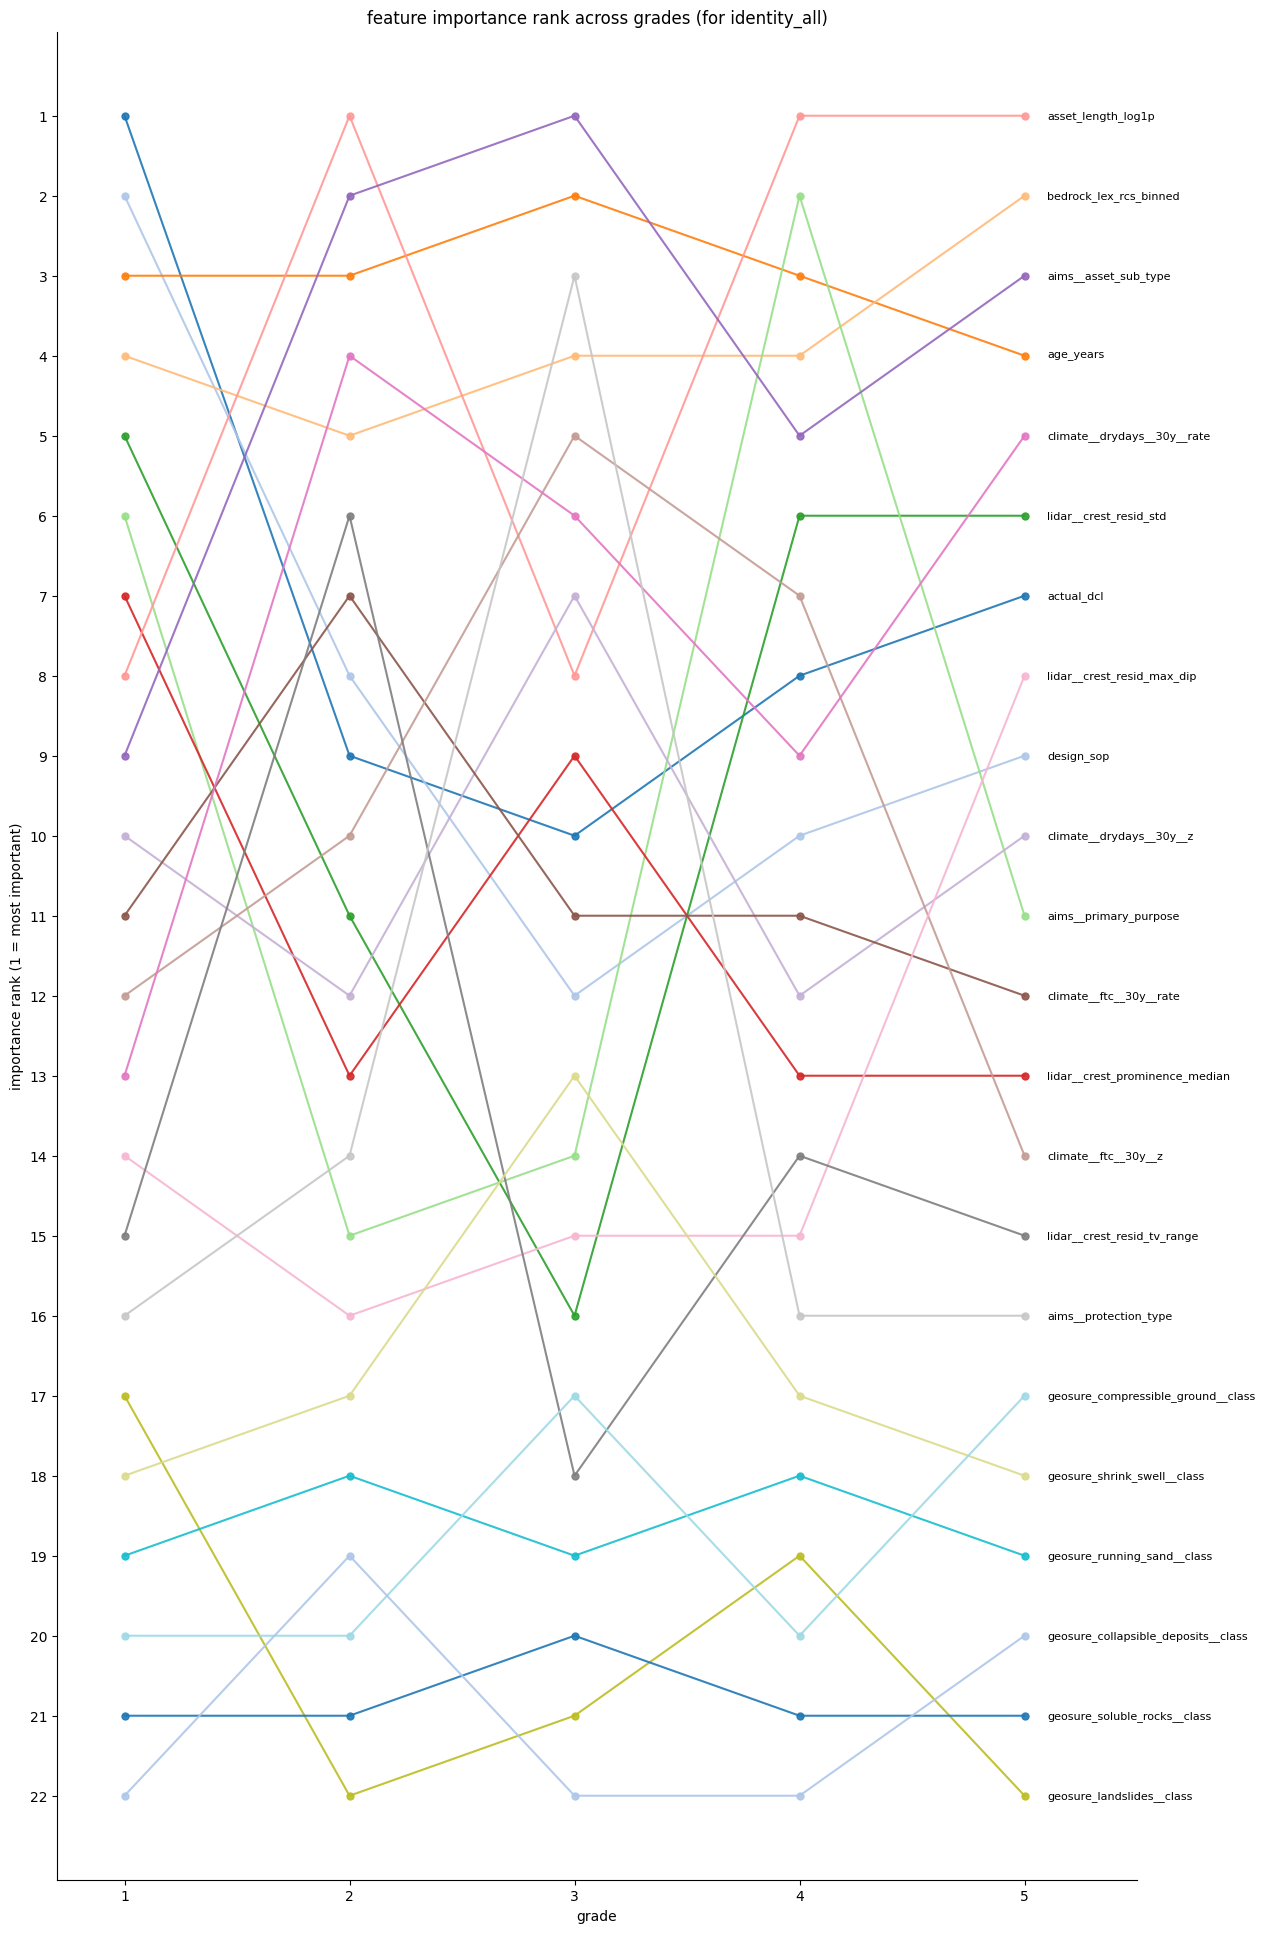

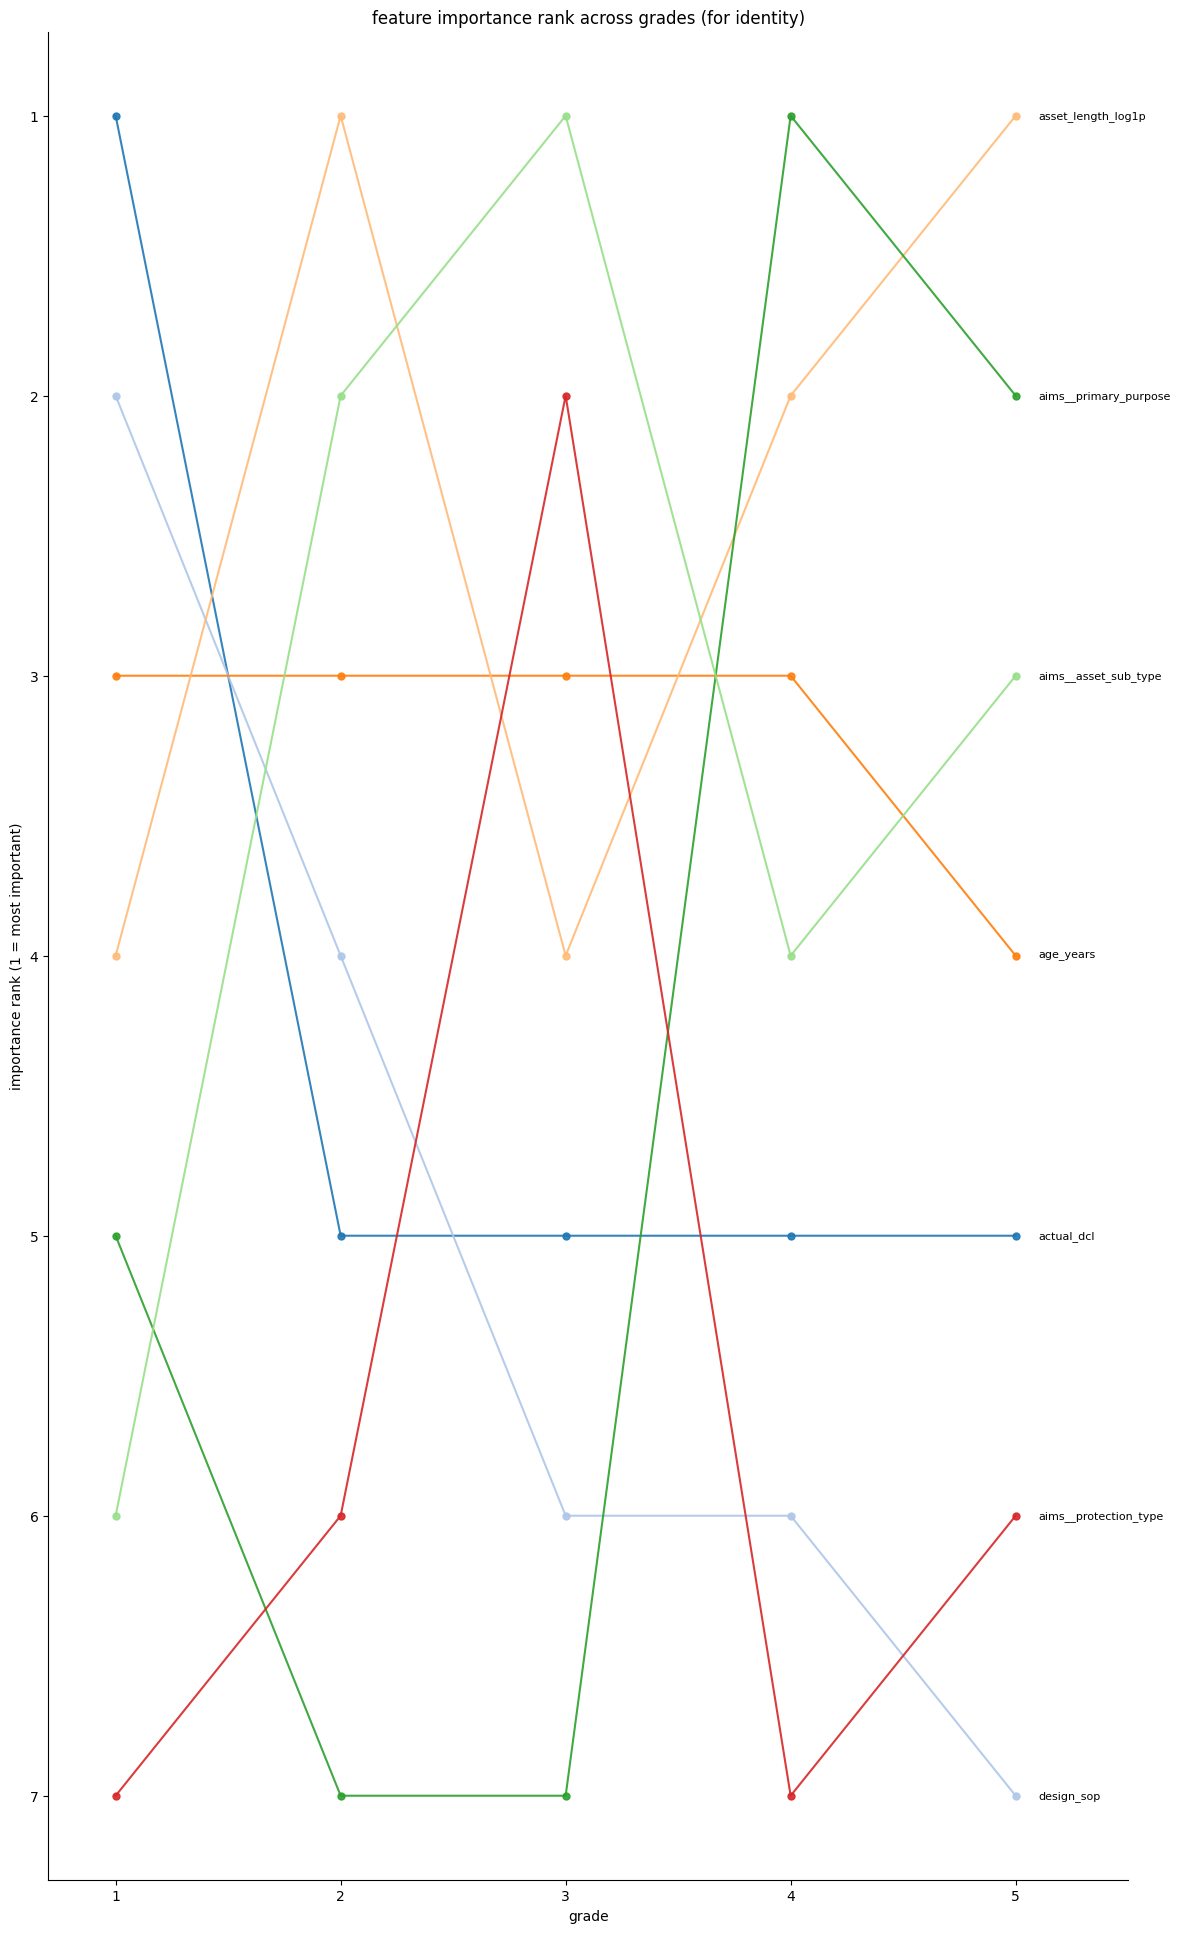

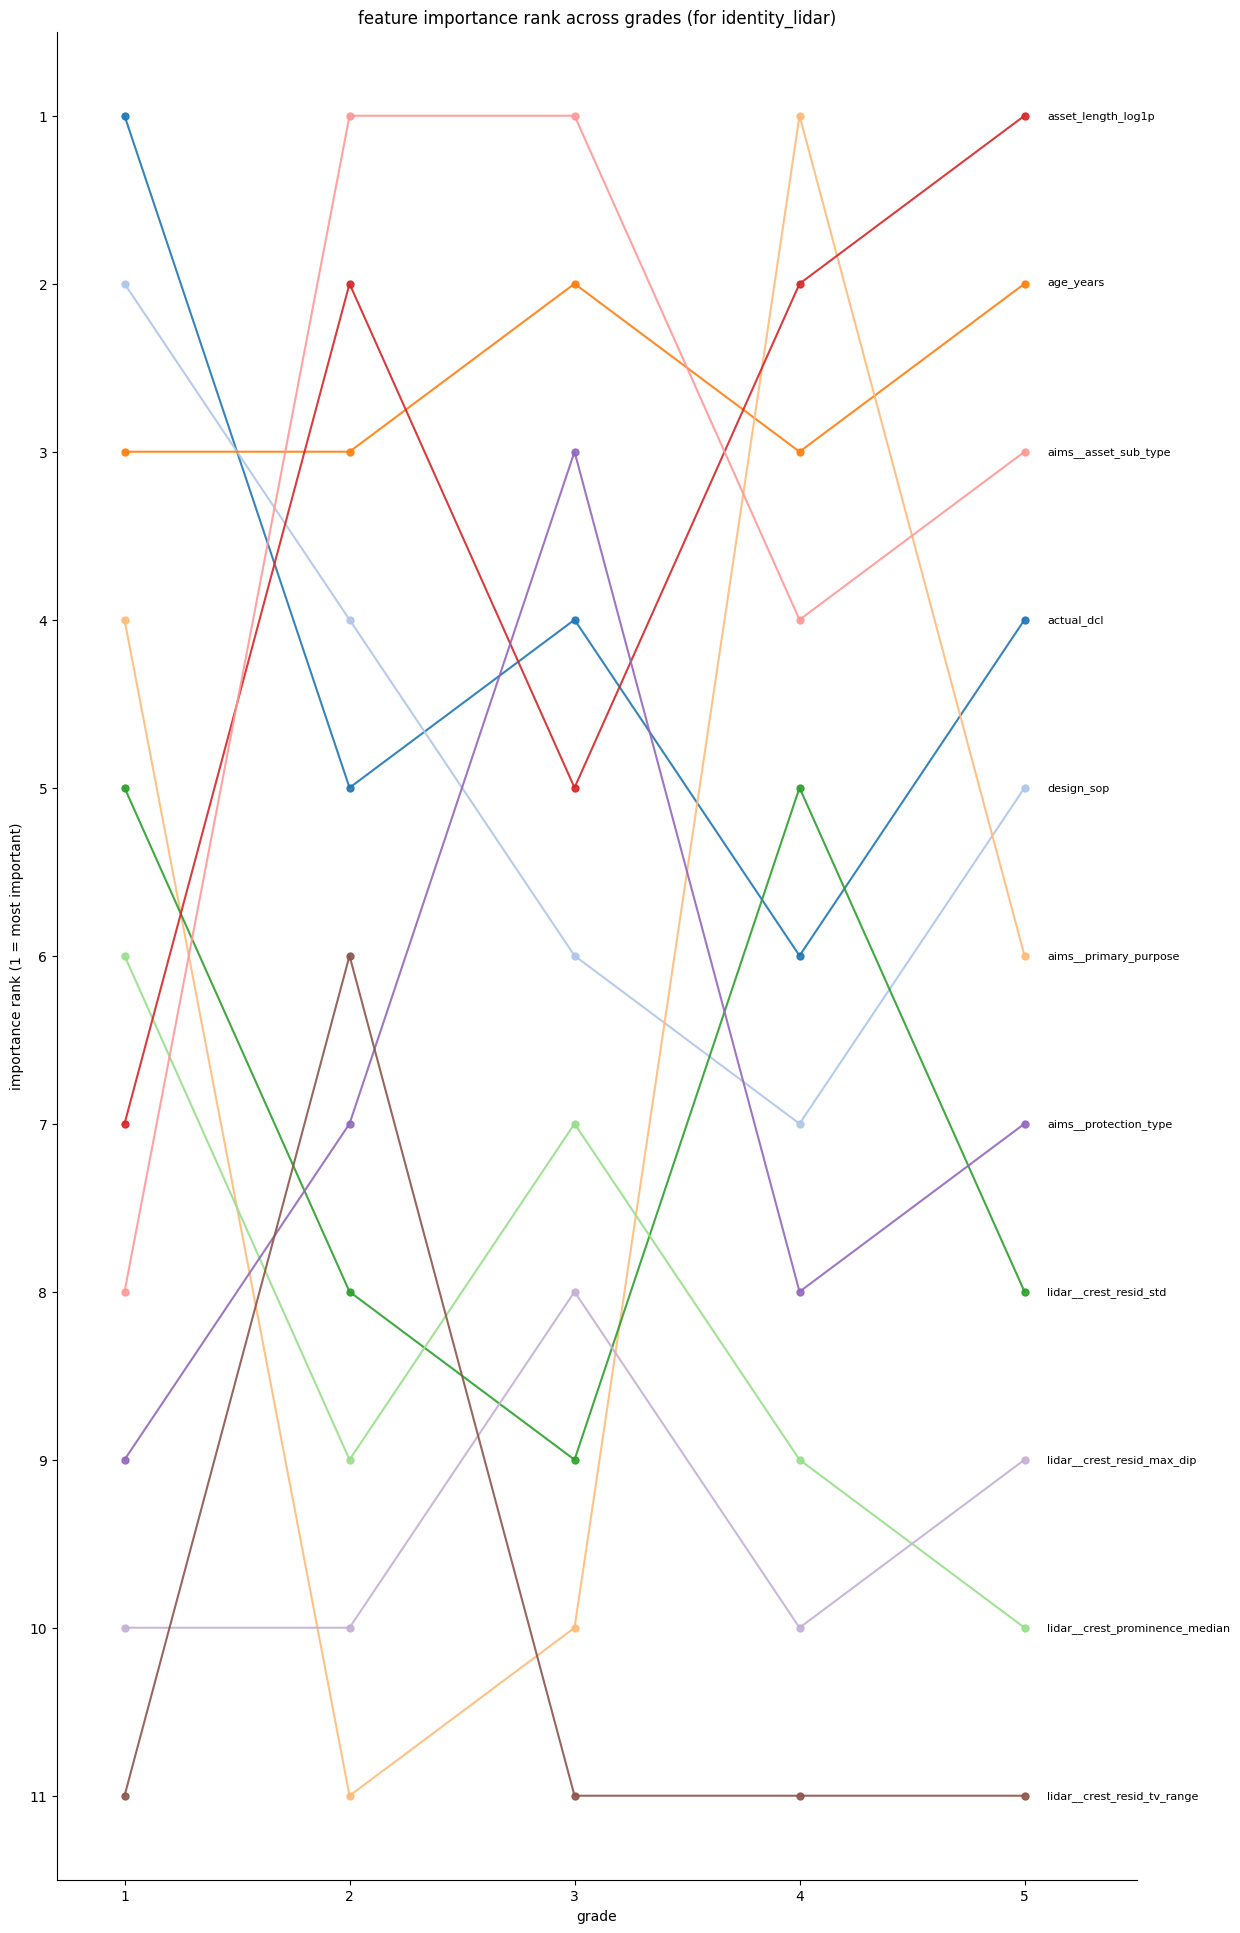

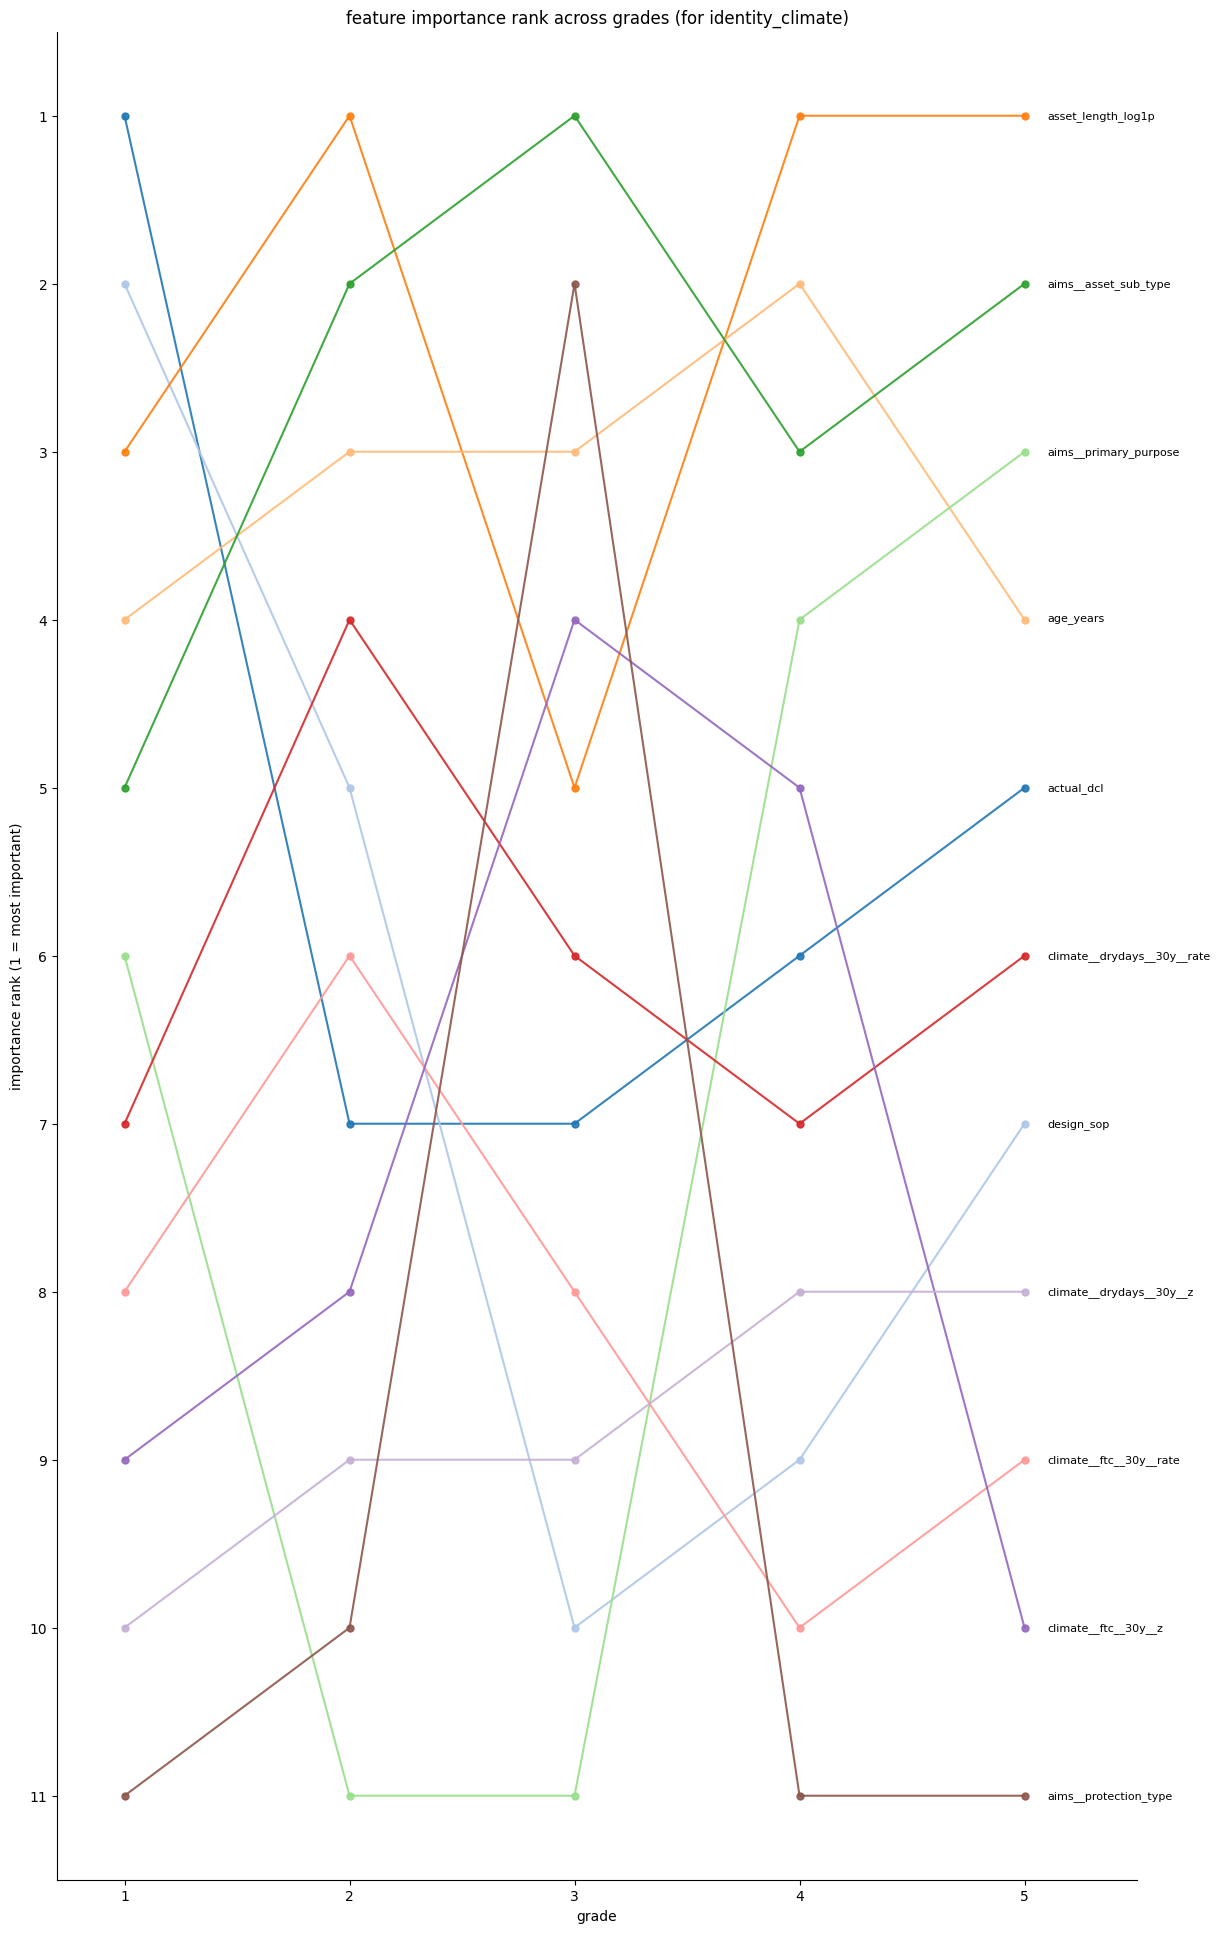

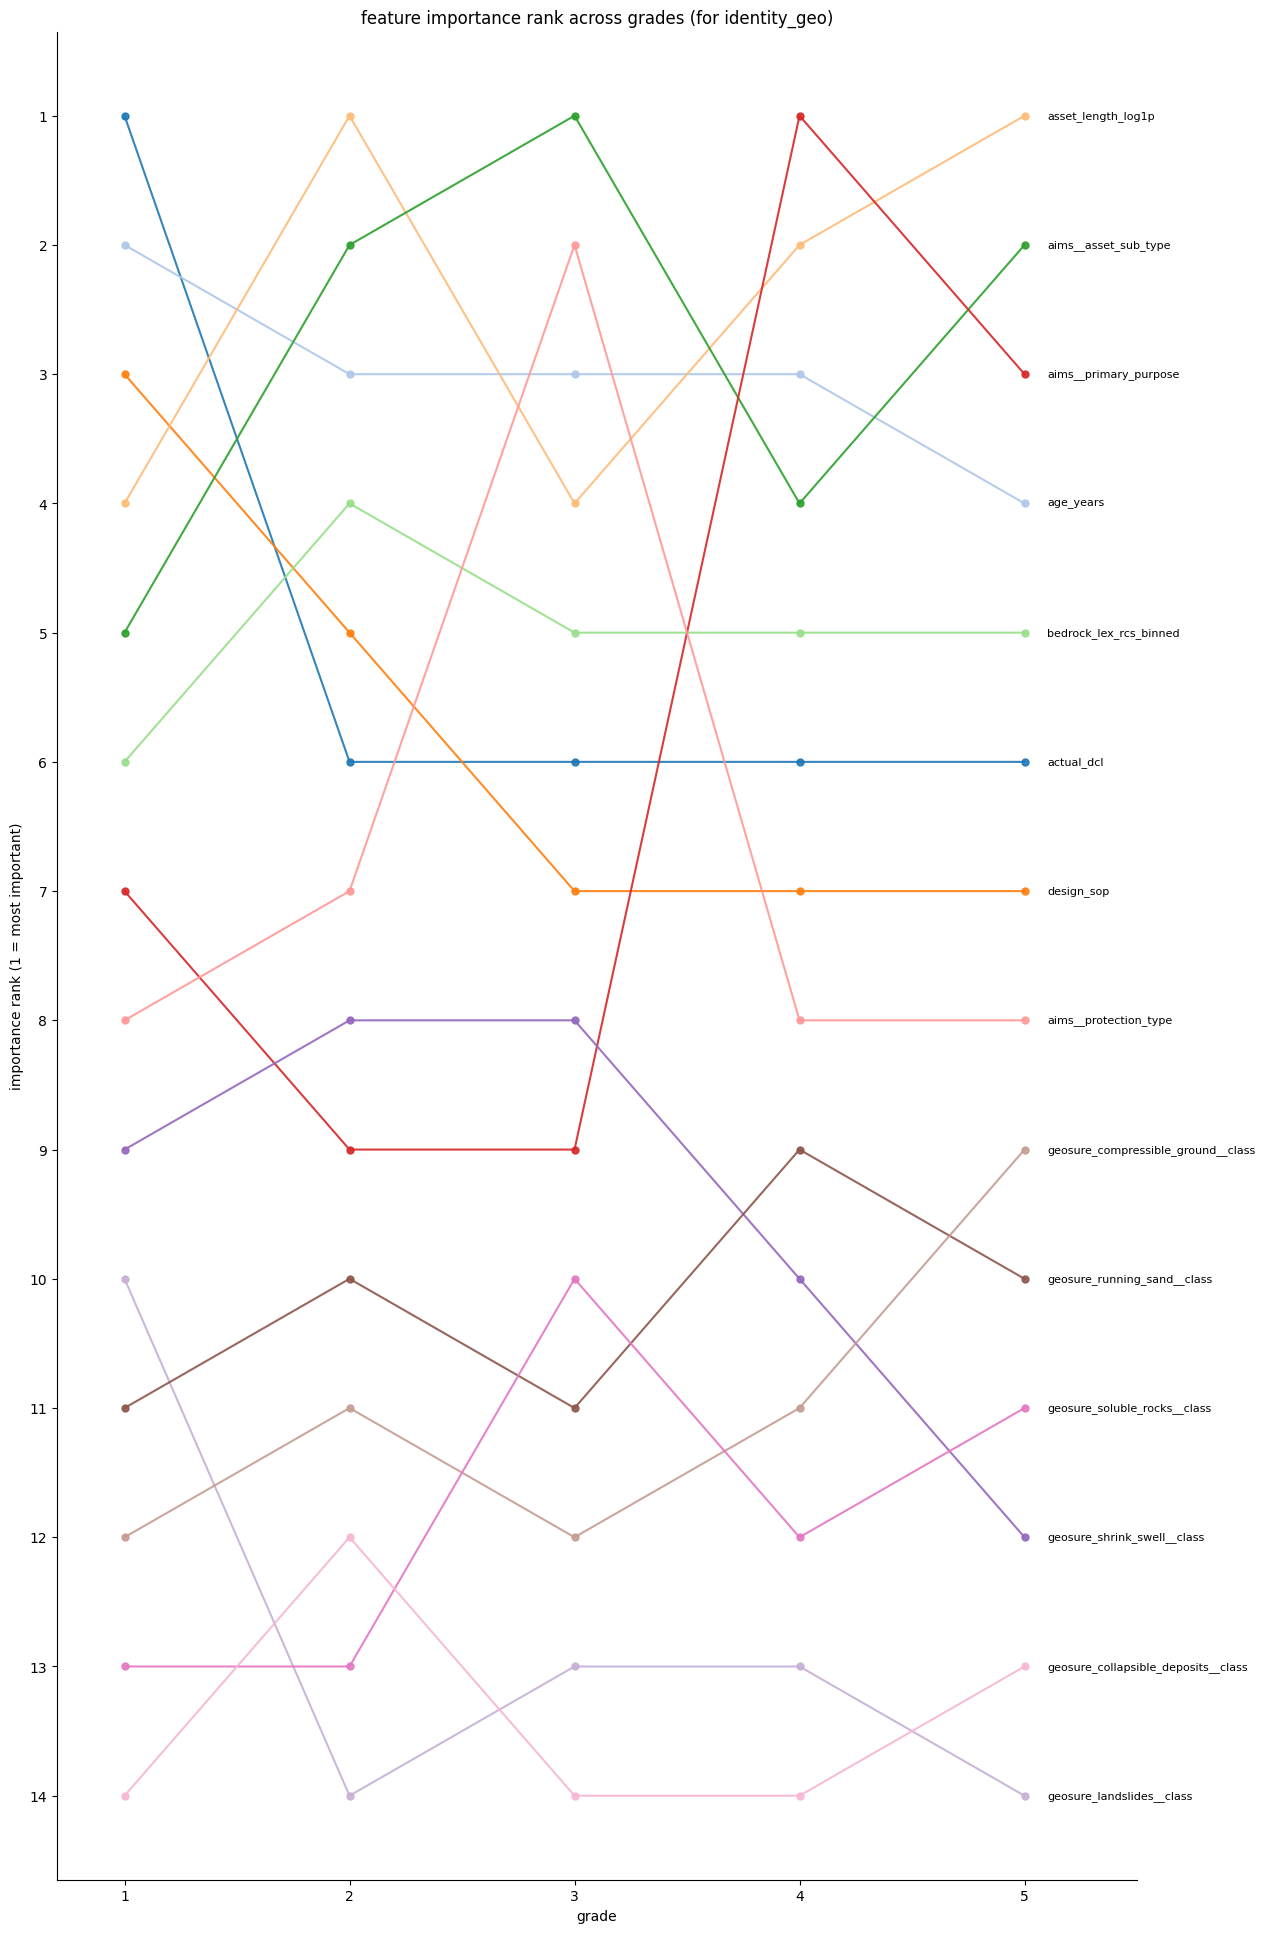

In [35]:
import matplotlib.pyplot as plt 

for feature_set in ["identity_all", "identity", "identity_lidar", "identity_climate", "identity_geo"]:

    bump = (
        feature_importance.filter(pl.col("feature_set") == feature_set)
        .with_columns(pl.col("mean_abs_shap").rank(descending=True).over("grade").alias("plot_rank"))
        .sort("feature", "grade")
    )

    # print(bump)



    grades = [1, 2, 3, 4, 5]

    # start with order for grade 1 importances

    features = bump.filter(pl.col("grade") == 1).sort("plot_rank").get_column("feature").to_list()


    fig, ax = plt.subplots(figsize=(24, 24))
    fig.subplots_adjust(left=0.25, right=0.70)   # canvas room for the endpoint labels

    cmap = plt.get_cmap("tab20")
    colours = {f: cmap(i % 20) for i, f in enumerate(features)}

    for f in features:
        sub = bump.filter(pl.col("feature") == f).sort("grade")

        xs = sub.get_column("grade").to_list()
        ys = sub.get_column("plot_rank").to_list()

        ax.plot(
            xs, 
            ys, 
            "-o", 
            linewidth=1.5, 
            markersize=5, 
            alpha=0.9,
            c=colours[f]
        )

        # ax.text(
        #     xs[0] - 0.10, 
        #     ys[0], 
        #     f, 
        #     ha="right", 
        #     va="center",
        #     fontsize=8, 
        #     clip_on=False
        # )

        ax.text(
            xs[-1] + 0.10, 
            ys[-1], 
            f, 
            ha="left", 
            va="center",
            fontsize=8, 
            clip_on=False
        )


    ax.set_xticks(grades)
    ax.set_yticks(range(1, len(features) + 1))
    ax.set_xlim(0.7, 5.5)
    ax.invert_yaxis() # rank 1 highest, at the top
    ax.set_xlabel("grade")
    ax.set_ylabel("importance rank (1 = most important)")
    ax.set_title(f"feature importance rank across grades (for {feature_set})")
    ax.spines[["top", "right"]].set_visible(False)

    plt.show()

i think this is a good visual representation that the usage of protection type falls only when the climate features are included. 

bedrock is the most stable feature in the all config, and at fairly high ranks. Nothing else stays so flat. 

this confirms dropping the six geosure features, which are lowest ranked at every grade. 

primary purpose is a high usage features specifically at higher grades - jumps up from 7 to 3 at grade 4. So it specifically indicates when an asset is in poor condition. 

the final information i want from these results before starting on a next experiment design is on the hyperparameter grid. I intend the next experiment to be tighter in terms of what features are used, but can use a finer grid to make sure its finding optimum configurations. need to know where to centre hyperparameters and what ranges/increments to include in the grid.

In [36]:
axes = ["max_iter", "max_leaf_nodes", "min_samples_leaf", "l2_regularization", "max_features"]

axis_effect = (
    cell_summary.filter(pl.col("feature_set").is_not_null())
    .with_columns(pl.col(axes).cast(pl.Float64))
    .unpivot(
        index=["feature_set", "cell_id", "pr_auc_ge4", "qwk"],
        on=axes,
        variable_name="axis",
        value_name="level",
    )
    .group_by("axis", "level")
    .agg(
        pl.col("pr_auc_ge4").mean().alias("pr_auc"),
        pl.col("qwk").mean().alias("qwk"),
        pl.len().alias("n_cells"),
    )
    .sort("axis", "level")
)

axis_effect

axis,level,pr_auc,qwk,n_cells
str,f64,f64,f64,u32
"""l2_regularization""",0.0,0.173372,0.27323,85
"""l2_regularization""",0.1,0.170011,0.263747,85
"""l2_regularization""",1.0,0.174978,0.273671,80
"""max_features""",0.5,0.173914,0.271937,100
"""max_features""",0.7,0.17376,0.27293,75
…,…,…,…,…
"""max_leaf_nodes""",64.0,0.167226,0.255287,55
"""min_samples_leaf""",5.0,0.173747,0.272585,40
"""min_samples_leaf""",20.0,0.173096,0.268967,90


In [37]:
with pl.Config(tbl_rows=-1):
    print(axis_effect)

shape: (19, 5)
┌───────────────────┬───────┬──────────┬──────────┬─────────┐
│ axis              ┆ level ┆ pr_auc   ┆ qwk      ┆ n_cells │
│ ---               ┆ ---   ┆ ---      ┆ ---      ┆ ---     │
│ str               ┆ f64   ┆ f64      ┆ f64      ┆ u32     │
╞═══════════════════╪═══════╪══════════╪══════════╪═════════╡
│ l2_regularization ┆ 0.0   ┆ 0.173372 ┆ 0.27323  ┆ 85      │
│ l2_regularization ┆ 0.1   ┆ 0.170011 ┆ 0.263747 ┆ 85      │
│ l2_regularization ┆ 1.0   ┆ 0.174978 ┆ 0.273671 ┆ 80      │
│ max_features      ┆ 0.5   ┆ 0.173914 ┆ 0.271937 ┆ 100     │
│ max_features      ┆ 0.7   ┆ 0.17376  ┆ 0.27293  ┆ 75      │
│ max_features      ┆ 1.0   ┆ 0.170164 ┆ 0.264978 ┆ 75      │
│ max_iter          ┆ 25.0  ┆ 0.178827 ┆ 0.282921 ┆ 65      │
│ max_iter          ┆ 50.0  ┆ 0.176341 ┆ 0.278208 ┆ 50      │
│ max_iter          ┆ 100.0 ┆ 0.175548 ┆ 0.277833 ┆ 45      │
│ max_iter          ┆ 200.0 ┆ 0.167774 ┆ 0.258582 ┆ 50      │
│ max_iter          ┆ 400.0 ┆ 0.161414 ┆ 0.245122 ┆ 40 

so the first thing i see is that i was wrong about not being worried about overfitting. The optimum max_iter and max_leaf_nodes are not in my grid, and it looks like i will have to restrict the model even more to find the best outcome. These models have been overfitting really fast. 

In comparison, l2 regularisation is basically flat. i think any difference here is probably noise and i can leave it out of the next grid. 

in the next experiment, i will have lower max_iter, but also half (or tune) the learning rate - it was flatly 0.1 in this experiment. if the learning rate is 0.05 then the max_iter=25 row will have to become max_iter=50 in the next grid. 

so final grid for next experiment:
    - drop L2 (or keep on/off)
    - narrow for max features and min samples leaf
    - fine and extended for max iter and max leaf nodes
    - try learning rates of 0.025 and 0.05
    - add coarse tuning of max_bins and max_depth
    - tighter feature subsets to try

In [38]:
cm_cells = (
    cell_summary.filter(pl.col("wants_full_shap") | pl.col("feature_set").is_null())
    .select("cell_id", "model", "feature_set")
    .with_columns(
        pl.coalesce(pl.col("feature_set"), pl.col("model")).alias("label")
    )
    .sort("feature_set", "model")
)

cm_oof = pl.concat(
    [
        pl.read_parquet(oof_dir / f"{cell_id}.parquet").select(
            "cell_id", "y_true", "y_pred_argmax"
        )
        for cell_id in cm_cells.get_column("cell_id")
    ]
).join(cm_cells, on="cell_id", how="left", validate="m:1")

In [39]:
GRADE_FRAME = pl.DataFrame({"grade": [1, 2, 3, 4, 5]}, schema={"grade": pl.Int8})


def confusion(oof: pl.DataFrame, by_fold: bool = False) -> pl.DataFrame:
    """5x5 confusion, long form, zeros filled so all 25 cells exist per group."""
    keys = ["cell_id", "label"] + (["fold_id"] if by_fold else [])

    counted = oof.group_by([*keys, "y_true", "y_pred_argmax"]).agg(
        pl.len().cast(pl.Int32).alias("n")
    )

    grid = (
        oof.select(keys)
        .unique()
        .join(GRADE_FRAME.rename({"grade": "y_true"}), how="cross")
        .join(GRADE_FRAME.rename({"grade": "y_pred_argmax"}), how="cross")
    )

    return (
        grid.join(counted, on=[*keys, "y_true", "y_pred_argmax"], how="left")
        .with_columns(pl.col("n").fill_null(0).cast(pl.Int32))
        .sort([*keys, "y_true", "y_pred_argmax"])
    )


cm = confusion(cm_oof)

In [40]:
import seaborn as sns

ALL_GRADES = [1, 2, 3, 4, 5]


def plot_confusion_matrix(cm_wide: pl.DataFrame, title: str, ax):
    for grade in ALL_GRADES:
        if str(grade) not in cm_wide.columns:
            cm_wide = cm_wide.with_columns(pl.lit(0).cast(pl.Int32).alias(str(grade)))

    pred_cols = [str(g) for g in ALL_GRADES]
    counts = cm_wide.select(pred_cols).to_numpy().astype(float)

    row_sums = counts.sum(axis=1, keepdims=True)
    display = np.divide(counts, row_sums, out=np.zeros_like(counts), where=row_sums != 0)

    sns.heatmap(
        display,
        cmap="viridis",
        vmin=0,
        vmax=1,
        cbar=False,
        xticklabels=pred_cols,
        yticklabels=cm_wide["y_true"].to_list(),
        ax=ax,
        linewidths=0.5,
        linecolor="black",
    )

    for i in range(counts.shape[0]):
        for j in range(counts.shape[1]):
            ax.text(
                j + 0.5,
                i + 0.5,
                f"{display[i, j]:.0%}\n({int(counts[i, j])})",
                ha="center",
                va="center",
                fontsize=8,
                color="white" if display[i, j] < 0.6 else "black",
            )

    ax.set_xlabel("Predicted grade")
    ax.set_ylabel("True grade")
    ax.set_title(title, fontsize=10)
    return ax

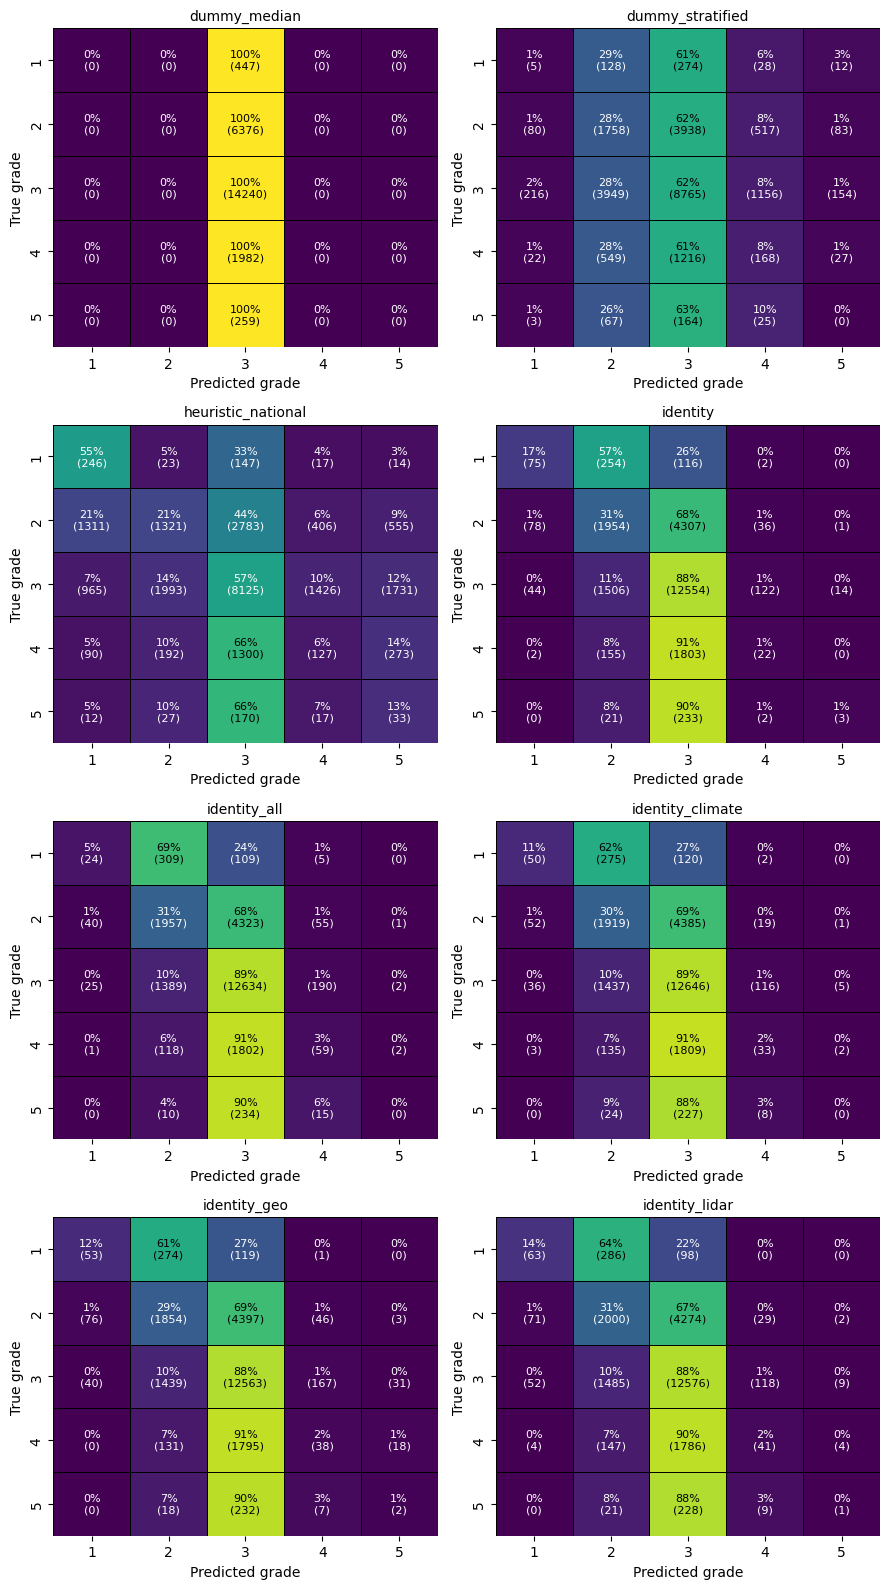

In [41]:
labels = cm_cells.get_column("label").to_list()
ncols = 2
nrows = -(-len(labels) // ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(9, 4 * nrows))
axes = axes.flatten()

for ax, label in zip(axes, labels):
    cm_wide = (
        cm.filter(pl.col("label") == label)
        .select("y_true", "y_pred_argmax", "n")
        .pivot(on="y_pred_argmax", index="y_true", values="n")
        .sort("y_true")
    )
    plot_confusion_matrix(cm_wide, title=label, ax=ax)

for ax in axes[len(labels):]:
    ax.axis("off")

fig.tight_layout()
plt.show()

conf matrices make the heuristic look good. We know that this is due to its spread rather than its skill, and this reminds me that i have not swept the argmax threashold in this notebook yet. 

didn't do this yet because I don't want to sweep all cells, just pick the ones it makes sense to do so for (the winners from analysis above)

In [42]:
sweep_cells = pl.concat(
    [
        cell_summary.filter(pl.col("feature_set") == feature_set)
        .sort("pr_auc_ge4", descending=True)
        .head(1)
        .select("cell_id", "model", "feature_set", "pr_auc_ge4", "qwk")
        for feature_set in ["identity_lidar", "identity"]
    ]
    + [
        cell_summary.filter(pl.col("feature_set").is_null()).select(
            "cell_id", "model", "feature_set", "pr_auc_ge4", "qwk"
        )
    ]
).with_columns(pl.coalesce(pl.col("feature_set"), pl.col("model")).alias("label"))

sweep_oof = pl.concat(
    [
        pl.read_parquet(oof_dir / f"{cell_id}.parquet").select(
            "cell_id",
            "fold_id",
            "asset_id",
            "y_true",
            pl.sum_horizontal("proba_4", "proba_5").alias("score"),
        )
        for cell_id in sweep_cells.get_column("cell_id")
    ]
).join(sweep_cells, on="cell_id", how="left", validate="m:1").with_columns(
    (pl.col("y_true") >= 4).alias("is_positive")
)

sweep_cells

cell_id,model,feature_set,pr_auc_ge4,qwk,label
str,str,str,f64,f64,str
"""319ad6382d9c""","""hgb""","""identity_lidar""",0.194096,0.295196,"""identity_lidar"""
"""fbf580e9437e""","""hgb""","""identity""",0.180398,0.302242,"""identity"""
"""e7cf4e14bac4""","""heuristic_national""",null,0.098838,0.185143,"""heuristic_national"""
"""b4b2c94d306e""","""dummy_stratified""",null,0.097513,-0.000851,"""dummy_stratified"""
"""71e772a4288b""","""dummy_median""",null,0.096583,0.0,"""dummy_median"""


In [43]:
sweep_oof

cell_id,fold_id,asset_id,y_true,score,model,feature_set,pr_auc_ge4,qwk,label,is_positive
str,i8,i64,i8,f64,str,str,f64,f64,str,bool
"""319ad6382d9c""",3,100006,3,0.05538,"""hgb""","""identity_lidar""",0.194096,0.295196,"""identity_lidar""",false
"""319ad6382d9c""",3,100010,3,0.035981,"""hgb""","""identity_lidar""",0.194096,0.295196,"""identity_lidar""",false
"""319ad6382d9c""",3,100015,4,0.05155,"""hgb""","""identity_lidar""",0.194096,0.295196,"""identity_lidar""",true
"""319ad6382d9c""",3,100016,3,0.072996,"""hgb""","""identity_lidar""",0.194096,0.295196,"""identity_lidar""",false
"""319ad6382d9c""",3,100017,3,0.063716,"""hgb""","""identity_lidar""",0.194096,0.295196,"""identity_lidar""",false
…,…,…,…,…,…,…,…,…,…,…
"""71e772a4288b""",9,99960,3,0.0,"""dummy_median""",null,0.096583,0.0,"""dummy_median""",false
"""71e772a4288b""",1,99963,3,0.0,"""dummy_median""",null,0.096583,0.0,"""dummy_median""",false
"""71e772a4288b""",6,99966,3,0.0,"""dummy_median""",null,0.096583,0.0,"""dummy_median""",false


In [44]:
sweep_curve = (
    sweep_oof.group_by("cell_id", "label", "score")
    .agg(
        pl.len().alias("n_at_score"),
        pl.col("is_positive").sum().alias("n_pos_at_score"),
    )
    .sort("cell_id", "score", descending=[False, True])
    .with_columns(
        pl.col("n_at_score").cum_sum().over("cell_id").alias("n_flagged"),
        pl.col("n_pos_at_score").cum_sum().over("cell_id").alias("n_true_positive"),
        pl.col("n_at_score").sum().over("cell_id").alias("n_total"),
        pl.col("n_pos_at_score").sum().over("cell_id").alias("n_positive_total"),
    )
    .with_columns(
        (pl.col("n_true_positive") / pl.col("n_flagged")).alias("precision"),
        (pl.col("n_true_positive") / pl.col("n_positive_total")).alias("recall"),
        (pl.col("n_flagged") / pl.col("n_total")).alias("flagged_pct"),
        (pl.col("n_positive_total") / pl.col("n_total")).alias("base_rate"),
    )
    .with_columns((pl.col("precision") / pl.col("base_rate")).alias("lift"))
    .select(
        "label", "score", "n_flagged", "flagged_pct", "n_true_positive",
        "precision", "recall", "lift", "base_rate",
    )
)

sweep_curve.filter(pl.col("label") == "identity_lidar").filter(
    pl.col("n_flagged").is_between(500, 8000)
).gather_every(50)

label,score,n_flagged,flagged_pct,n_true_positive,precision,recall,lift,base_rate
str,f64,u32,f64,u32,f64,f64,f64,f64
"""identity_lidar""",0.315332,500,0.021456,145,0.29,0.064703,3.015689,0.096164
"""identity_lidar""",0.305914,550,0.023601,159,0.289091,0.07095,3.006236,0.096164
"""identity_lidar""",0.298305,600,0.025747,170,0.283333,0.075859,2.946363,0.096164
"""identity_lidar""",0.291322,650,0.027892,185,0.284615,0.082552,2.959695,0.096164
"""identity_lidar""",0.285793,700,0.030038,195,0.278571,0.087015,2.896845,0.096164
…,…,…,…,…,…,…,…,…
"""identity_lidar""",0.099996,7776,0.333677,1282,0.164866,0.572066,1.714432,0.096164
"""identity_lidar""",0.099474,7827,0.335865,1287,0.164431,0.574297,1.709904,0.096164
"""identity_lidar""",0.099029,7878,0.338054,1291,0.163874,0.576082,1.704115,0.096164


this output is pretty strong. the lifts are high, promising that the skill of the models can be converted into predictions with decent precision/accuracy. But it looks lke the lift is still climbing as n decreases down to 500. So i am going to increase the range of the sweep. 

In [45]:

with pl.Config(tbl_rows=-1):
    curve = sweep_curve.filter(pl.col("label") == "identity_lidar").filter(
        pl.col("n_flagged").is_between(1, 8000)
    ).gather_every(50)

    print(curve)

shape: (159, 9)
┌────────────┬──────────┬───────────┬────────────┬───┬───────────┬──────────┬──────────┬───────────┐
│ label      ┆ score    ┆ n_flagged ┆ flagged_pc ┆ … ┆ precision ┆ recall   ┆ lift     ┆ base_rate │
│ ---        ┆ ---      ┆ ---       ┆ t          ┆   ┆ ---       ┆ ---      ┆ ---      ┆ ---       │
│ str        ┆ f64      ┆ u32       ┆ ---        ┆   ┆ f64       ┆ f64      ┆ f64      ┆ f64       │
│            ┆          ┆           ┆ f64        ┆   ┆           ┆          ┆          ┆           │
╞════════════╪══════════╪═══════════╪════════════╪═══╪═══════════╪══════════╪══════════╪═══════════╡
│ identity_l ┆ 0.667675 ┆ 1         ┆ 0.000043   ┆ … ┆ 0.0       ┆ 0.0      ┆ 0.0      ┆ 0.096164  │
│ idar       ┆          ┆           ┆            ┆   ┆           ┆          ┆          ┆           │
│ identity_l ┆ 0.492818 ┆ 51        ┆ 0.002188   ┆ … ┆ 0.352941  ┆ 0.008032 ┆ 3.67021  ┆ 0.096164  │
│ idar       ┆          ┆           ┆            ┆   ┆           ┆         

easier just to plot then try and find a good range to display in the table

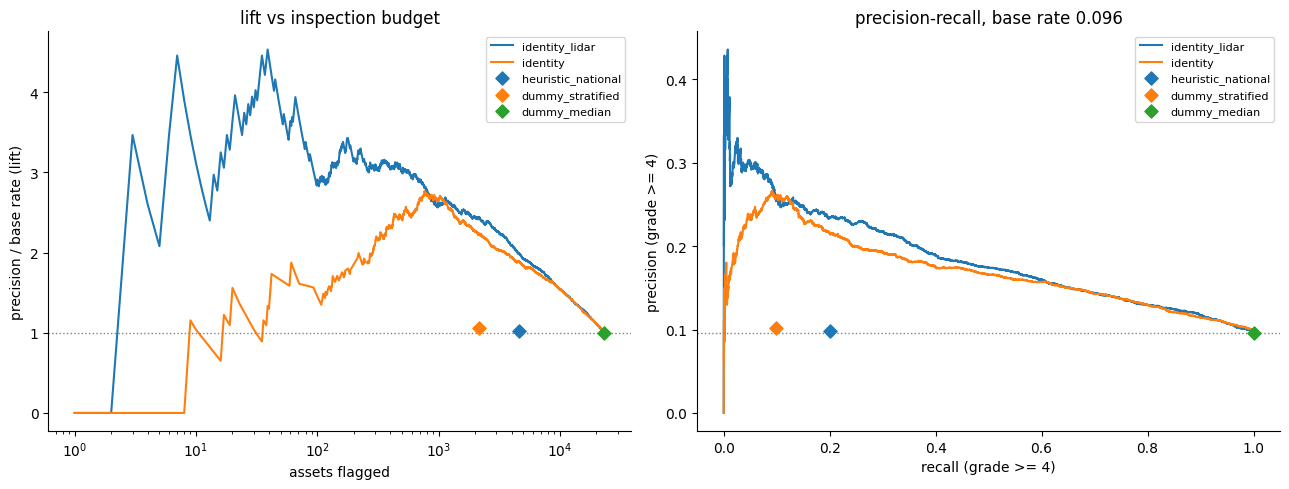

In [46]:
model_labels = ["identity_lidar", "identity"]
point_labels = ["heuristic_national", "dummy_stratified", "dummy_median"]
base_rate = sweep_curve.get_column("base_rate").max()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for label in model_labels:
    curve = sweep_curve.filter(pl.col("label") == label).sort("n_flagged")
    axes[0].plot(curve["n_flagged"], curve["lift"], label=label, linewidth=1.5)
    axes[1].plot(curve["recall"], curve["precision"], label=label, linewidth=1.5)

for label in point_labels:
    point = (
        sweep_curve.filter((pl.col("label") == label) & (pl.col("n_flagged") > 0))
        .sort("lift", descending=True)
        .head(1)
    )
    axes[0].scatter(point["n_flagged"], point["lift"], marker="D", s=45, zorder=5, label=label)
    axes[1].scatter(point["recall"], point["precision"], marker="D", s=45, zorder=5, label=label)

axes[0].axhline(1.0, color="grey", linestyle=":", linewidth=1)
axes[0].set_xscale("log")
axes[0].set_xlabel("assets flagged")
axes[0].set_ylabel("precision / base rate (lift)")
axes[0].set_title("lift vs inspection budget")

axes[1].axhline(base_rate, color="grey", linestyle=":", linewidth=1)
axes[1].set_xlabel("recall (grade >= 4)")
axes[1].set_ylabel("precision (grade >= 4)")
axes[1].set_title(f"precision-recall, base rate {base_rate:.3f}")

for ax in axes:
    ax.legend(fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()

maybe easier was an not the right way to put it, but this is an interesting output so worthwhile :) 

this is a really important figure for the project. First, visual proof that the models learn skill that the heuristics don't have. The heuristic sits on the same line as the dummies, and its the "no skill" horisontal. 

Second, lidar gain is nearly all in the top of the condition ranking. the ranking decending by the probabily the grade = 4 plus the probality the grade = 5 for each asset. This means that lidar is specifically helping for assets in poorer conditions, and this is really important. These are the assets that any screening tool is actually trying to identify. Specifically, its increasing the precision of assets flagged as poor (4 or 5) by the model. Its worth noting that in absolute terms these precision grades are still pretty underwhelming and a way away from operationally useful (max of 0.4, will have to look at some comparisons in literature for other infrastructure condition predictions but i would imagine it gets up to 0.8 ish maybe?)

the reason the shape of the graph after adding lidar is so interesting is that a screening tool is likely to only take the ~ 100 - 200 assets that its most confident about and raise them as deterioration risks to a human. Lidar specifically improves the precision of these 100 to 200 assets. The curves are the same after 1000 assets, so they have very similar overall scores in the metrics we showed above, but lidar still has a very important separation in an area that we werent able to see just from the tables. 



im pleased with this finding, and im also going to quickly look at the curves for the other configs to compare. 

In [47]:
all_feature_sets = ["identity", "identity_geo", "identity_climate", "identity_lidar", "identity_all"]

sweep_cells = pl.concat(
    [
        cell_summary.filter(pl.col("feature_set") == feature_set)
        .sort("pr_auc_ge4", descending=True)
        .head(1)
        .select("cell_id", "model", "feature_set", "pr_auc_ge4", "qwk")
        for feature_set in all_feature_sets
    ]
    + [
        cell_summary.filter(pl.col("feature_set").is_null()).select(
            "cell_id", "model", "feature_set", "pr_auc_ge4", "qwk"
        )
    ]
).with_columns(pl.coalesce(pl.col("feature_set"), pl.col("model")).alias("label"))

sweep_oof = pl.concat(
    [
        pl.read_parquet(oof_dir / f"{cell_id}.parquet").select(
            "cell_id",
            "fold_id",
            "asset_id",
            "y_true",
            pl.sum_horizontal("proba_4", "proba_5").alias("score"),
        )
        for cell_id in sweep_cells.get_column("cell_id")
    ]
).join(sweep_cells, on="cell_id", how="left", validate="m:1").with_columns(
    (pl.col("y_true") >= 4).alias("is_positive")
)

sweep_curve = (
    sweep_oof.group_by("cell_id", "label", "score")
    .agg(
        pl.len().alias("n_at_score"),
        pl.col("is_positive").sum().alias("n_pos_at_score"),
    )
    .sort("cell_id", "score", descending=[False, True])
    .with_columns(
        pl.col("n_at_score").cum_sum().over("cell_id").alias("n_flagged"),
        pl.col("n_pos_at_score").cum_sum().over("cell_id").alias("n_true_positive"),
        pl.col("n_at_score").sum().over("cell_id").alias("n_total"),
        pl.col("n_pos_at_score").sum().over("cell_id").alias("n_positive_total"),
    )
    .with_columns(
        (pl.col("n_true_positive") / pl.col("n_flagged")).alias("precision"),
        (pl.col("n_true_positive") / pl.col("n_positive_total")).alias("recall"),
        (pl.col("n_flagged") / pl.col("n_total")).alias("flagged_pct"),
        (pl.col("n_positive_total") / pl.col("n_total")).alias("base_rate"),
    )
    .with_columns((pl.col("precision") / pl.col("base_rate")).alias("lift"))
    .select(
        "label", "score", "n_flagged", "flagged_pct", "n_true_positive",
        "precision", "recall", "lift", "base_rate",
    )
)

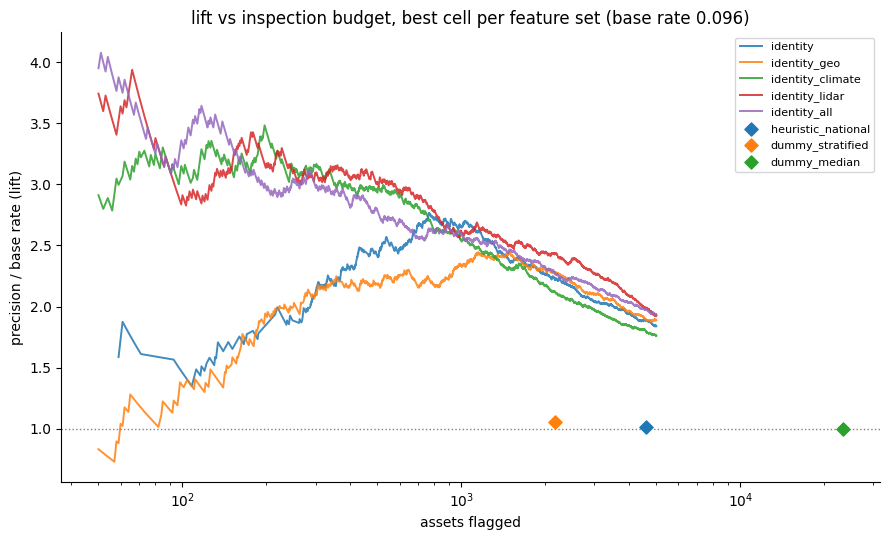

In [48]:
point_labels = ["heuristic_national", "dummy_stratified", "dummy_median"]
base_rate = sweep_curve.get_column("base_rate").max()

fig, ax = plt.subplots(figsize=(9, 5.5))

for feature_set in all_feature_sets:
    curve = (
        sweep_curve.filter(pl.col("label") == feature_set)
        .filter(pl.col("n_flagged").is_between(50, 5000))
        .sort("n_flagged")
    )
    ax.plot(
        curve["n_flagged"],
        curve["lift"],
        label=feature_set,
        linewidth=1.4,
        alpha=0.85,
    )

for label in point_labels:
    point = (
        sweep_curve.filter((pl.col("label") == label) & (pl.col("n_flagged") > 0))
        .sort("lift", descending=True)
        .head(1)
    )
    ax.scatter(point["n_flagged"], point["lift"], marker="D", s=45, zorder=5, label=label)

ax.axhline(1.0, color="grey", linestyle=":", linewidth=1)
ax.set_xscale("log")
ax.set_xlabel("assets flagged")
ax.set_ylabel("precision / base rate (lift)")
ax.set_title(f"lift vs inspection budget, best cell per feature set (base rate {base_rate:.3f})")
ax.legend(fontsize=8)
ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()

really interesting, probably overturns some of my earlier conclusions.

so geography still sucks. In fact, its actually making the model worse everywhere throught the curve. But some of the others are improving the skill in the important part of the curve, even if they end up with no lift after all assets are considered. 
in particular, climate is performing a similar role to lidar. 

is also worth pointing out that identity plus all isn't beating its parts, so theres still some redundancy/overlap/cost of increased feature space going on, and no useful interactions. 


big take away is that im no longer going to throw away climate features straight away. 

and also that these curves are drawn using the best cell per features, so it doesn't completely overturn the findings that looked at the average effect the features had across all configs. 

In [49]:
budgets = [100, 200, 500, 1000]
fitted_ids = cell_summary.filter(pl.col("feature_set").is_not_null()).get_column("cell_id")

lift_rows = []
for cell_id in fitted_ids:
    scored = (
        pl.read_parquet(oof_dir / f"{cell_id}.parquet")
        .select("y_true", pl.sum_horizontal("proba_4", "proba_5").alias("score"))
        .sort("score", descending=True)
    )
    positives = (scored.get_column("y_true") >= 4).to_numpy()
    base = positives.mean()

    for budget in budgets:
        precision = float(positives[:budget].mean())
        lift_rows.append(
            {
                "cell_id": cell_id,
                "budget": budget,
                "precision": precision,
                "lift": precision / base,
            }
        )

lift_at_k = pl.DataFrame(lift_rows).join(cell_meta, on="cell_id", how="left", validate="m:1")

lift_summ = lift_at_k.group_by("feature_set", "budget").agg(
    pl.col("lift").median().alias("median_lift"),
    pl.col("lift").min().alias("worst"),
    pl.col("lift").max().alias("best"),
    pl.len().alias("n_configs"),
).sort("budget", "feature_set")

lift_summ

feature_set,budget,median_lift,worst,best,n_configs
str,i64,f64,f64,f64,u32
"""identity""",100,1.715823,0.935904,3.119679,50
"""identity_all""",100,2.703722,0.935904,3.743614,50
"""identity_climate""",100,2.807711,1.247871,3.743614,50
"""identity_geo""",100,1.975797,0.831914,2.703722,50
"""identity_lidar""",100,2.807711,2.079786,3.847604,50
…,…,…,…,…,…
"""identity""",1000,2.365756,1.778217,2.786913,50
"""identity_all""",1000,2.454147,2.069387,2.71412,50
"""identity_climate""",1000,2.298163,1.84061,2.672525,50


In [50]:
with pl.Config(tbl_rows=-1):
    print(lift_summ)

shape: (20, 6)
┌──────────────────┬────────┬─────────────┬──────────┬──────────┬───────────┐
│ feature_set      ┆ budget ┆ median_lift ┆ worst    ┆ best     ┆ n_configs │
│ ---              ┆ ---    ┆ ---         ┆ ---      ┆ ---      ┆ ---       │
│ str              ┆ i64    ┆ f64         ┆ f64      ┆ f64      ┆ u32       │
╞══════════════════╪════════╪═════════════╪══════════╪══════════╪═══════════╡
│ identity         ┆ 100    ┆ 1.715823    ┆ 0.935904 ┆ 3.119679 ┆ 50        │
│ identity_all     ┆ 100    ┆ 2.703722    ┆ 0.935904 ┆ 3.743614 ┆ 50        │
│ identity_climate ┆ 100    ┆ 2.807711    ┆ 1.247871 ┆ 3.743614 ┆ 50        │
│ identity_geo     ┆ 100    ┆ 1.975797    ┆ 0.831914 ┆ 2.703722 ┆ 50        │
│ identity_lidar   ┆ 100    ┆ 2.807711    ┆ 2.079786 ┆ 3.847604 ┆ 50        │
│ identity         ┆ 200    ┆ 1.975797    ┆ 1.351861 ┆ 2.651727 ┆ 50        │
│ identity_all     ┆ 200    ┆ 2.677724    ┆ 1.143882 ┆ 3.431647 ┆ 50        │
│ identity_climate ┆ 200    ┆ 2.599732    ┆ 1.975

In [51]:
budgets = [100, 200, 500]
shortlist_labels = ["identity", "identity_lidar", "identity_climate", "heuristic_national"]

population = (
    sweep_oof.filter(pl.col("label") == "identity")
    .group_by("y_true")
    .agg((pl.len() / 23304).alias("share"))
    .with_columns(pl.lit("population").alias("label"), pl.lit(0).alias("budget"))
)

shortlists = []
for label in shortlist_labels:
    ranked = sweep_oof.filter(pl.col("label") == label).sort("score", descending=True)
    for budget in budgets:
        shortlists.append(
            ranked.head(budget)
            .group_by("y_true")
            .agg((pl.len() / budget).alias("share"))
            .with_columns(pl.lit(label).alias("label"), pl.lit(budget).alias("budget"))
        )

shortlist_profile = (
    pl.concat([population, *shortlists])
    .pivot(on="y_true", index=["label", "budget"], values="share")
    .fill_null(0.0)
    .sort("budget", "label")
)

with pl.Config(tbl_rows=-1):
    print(shortlist_profile)

shape: (13, 7)
┌────────────────────┬────────┬──────────┬──────────┬─────────┬──────────┬──────────┐
│ label              ┆ budget ┆ 3        ┆ 1        ┆ 4       ┆ 2        ┆ 5        │
│ ---                ┆ ---    ┆ ---      ┆ ---      ┆ ---     ┆ ---      ┆ ---      │
│ str                ┆ f64    ┆ f64      ┆ f64      ┆ f64     ┆ f64      ┆ f64      │
╞════════════════════╪════════╪══════════╪══════════╪═════════╪══════════╪══════════╡
│ population         ┆ 0.0    ┆ 0.611054 ┆ 0.019181 ┆ 0.08505 ┆ 0.273601 ┆ 0.011114 │
│ heuristic_national ┆ 100.0  ┆ 0.73     ┆ 0.0      ┆ 0.12    ┆ 0.13     ┆ 0.02     │
│ identity           ┆ 100.0  ┆ 0.76     ┆ 0.0      ┆ 0.11    ┆ 0.1      ┆ 0.03     │
│ identity_climate   ┆ 100.0  ┆ 0.64     ┆ 0.0      ┆ 0.26    ┆ 0.06     ┆ 0.04     │
│ identity_lidar     ┆ 100.0  ┆ 0.58     ┆ 0.0      ┆ 0.22    ┆ 0.14     ┆ 0.06     │
│ heuristic_national ┆ 200.0  ┆ 0.735    ┆ 0.0      ┆ 0.105   ┆ 0.145    ┆ 0.015    │
│ identity           ┆ 200.0  ┆ 0.685  

In [52]:
budget = 200
matrix_labels = ["identity", "identity_lidar", "identity_climate", "heuristic_national"]

binary_rows = []
for label in matrix_labels:
    ranked = sweep_oof.filter(pl.col("label") == label).sort("score", descending=True)
    flagged = (
        ranked.with_row_index("rank")
        .with_columns((pl.col("rank") < budget).alias("flagged"))
        .group_by("flagged", "is_positive")
        .agg(pl.len().alias("n"))
    )
    binary_rows.append(flagged.with_columns(pl.lit(label).alias("label")))

binary_matrix = (
    pl.concat(binary_rows)
    .pivot(on="is_positive", index=["label", "flagged"], values="n")
    .rename({"true": "actually_ge4", "false": "actually_below4"})
    .sort("label", "flagged", descending=[False, True])
)

binary_matrix

label,flagged,actually_ge4,actually_below4
str,bool,u32,u32
"""heuristic_national""",true,24,176
"""heuristic_national""",false,2217,20887
"""identity""",true,34,166
"""identity""",false,2207,20897
"""identity_climate""",true,66,134
"""identity_climate""",false,2175,20929
"""identity_lidar""",true,61,139
"""identity_lidar""",false,2180,20924


In [53]:
binary_summary = (
    binary_matrix.group_by("label")
    .agg(
        pl.col("actually_ge4").filter(pl.col("flagged")).first().alias("true_positive"),
        pl.col("actually_below4").filter(pl.col("flagged")).first().alias("false_positive"),
        pl.col("actually_ge4").filter(~pl.col("flagged")).first().alias("false_negative"),
        pl.col("actually_below4").filter(~pl.col("flagged")).first().alias("true_negative"),
    )
    .with_columns(
        (pl.col("true_positive") / (pl.col("true_positive") + pl.col("false_positive"))).alias("precision"),
        (pl.col("true_positive") / (pl.col("true_positive") + pl.col("false_negative"))).alias("recall"),
    )
    .with_columns((pl.col("precision") / 0.096164).alias("lift"))
    .sort("lift", descending=True)
)

binary_summary

label,true_positive,false_positive,false_negative,true_negative,precision,recall,lift
str,u32,u32,u32,u32,f64,f64,f64
"""identity_climate""",66,134,2175,20929,0.33,0.029451,3.431638
"""identity_lidar""",61,139,2180,20924,0.305,0.02722,3.171665
"""identity""",34,166,2207,20897,0.17,0.015172,1.767813
"""heuristic_national""",24,176,2217,20887,0.12,0.01071,1.247868


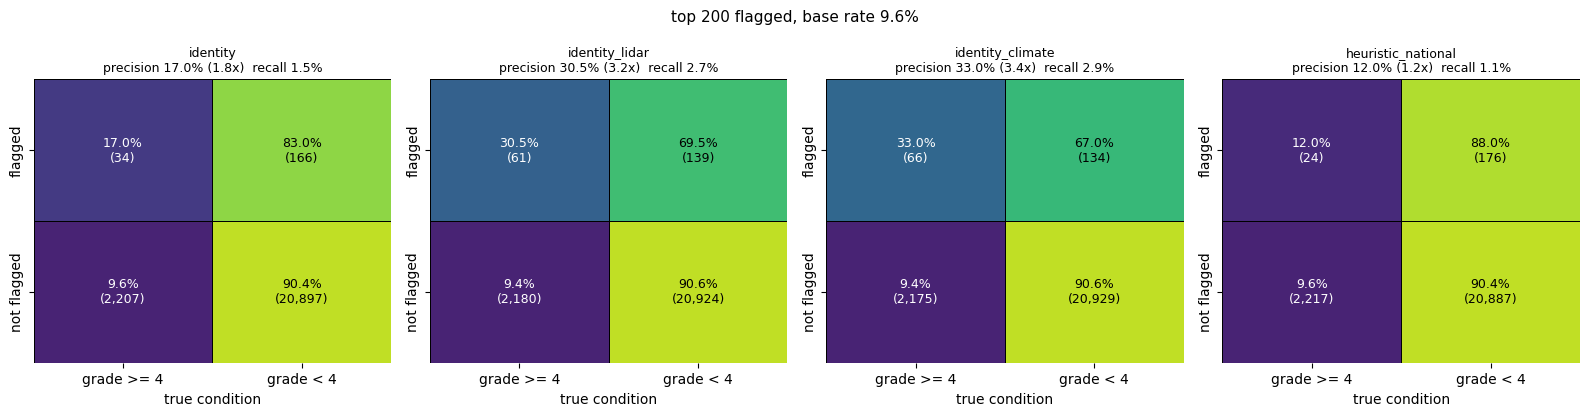

In [54]:
base_rate = 0.096164

fig, axes = plt.subplots(1, len(matrix_labels), figsize=(4 * len(matrix_labels), 4.2))

for ax, label in zip(axes, matrix_labels):
    ranked = sweep_oof.filter(pl.col("label") == label).sort("score", descending=True)
    positives = ranked.get_column("is_positive").to_numpy()

    true_positive = int(positives[:budget].sum())
    false_positive = budget - true_positive
    false_negative = int(positives[budget:].sum())
    true_negative = len(positives) - budget - false_negative

    counts = np.array([[true_positive, false_positive], [false_negative, true_negative]])
    shares = counts / counts.sum(axis=1, keepdims=True)

    sns.heatmap(
        shares,
        cmap="viridis",
        vmin=0,
        vmax=1,
        cbar=False,
        xticklabels=["grade >= 4", "grade < 4"],
        yticklabels=["flagged", "not flagged"],
        ax=ax,
        linewidths=0.5,
        linecolor="black",
    )

    for i in range(2):
        for j in range(2):
            ax.text(
                j + 0.5,
                i + 0.5,
                f"{shares[i, j]:.1%}\n({counts[i, j]:,})",
                ha="center",
                va="center",
                fontsize=9,
                color="white" if shares[i, j] < 0.6 else "black",
            )

    precision = true_positive / budget
    recall = true_positive / (true_positive + false_negative)
    ax.set_title(
        f"{label}\nprecision {precision:.1%} ({precision / base_rate:.1f}x)  recall {recall:.1%}",
        fontsize=9,
    )
    ax.set_xlabel("true condition")
    ax.set_ylabel("")

fig.suptitle(f"top {budget} flagged, base rate {base_rate:.1%}", fontsize=11)
fig.tight_layout()
plt.show()

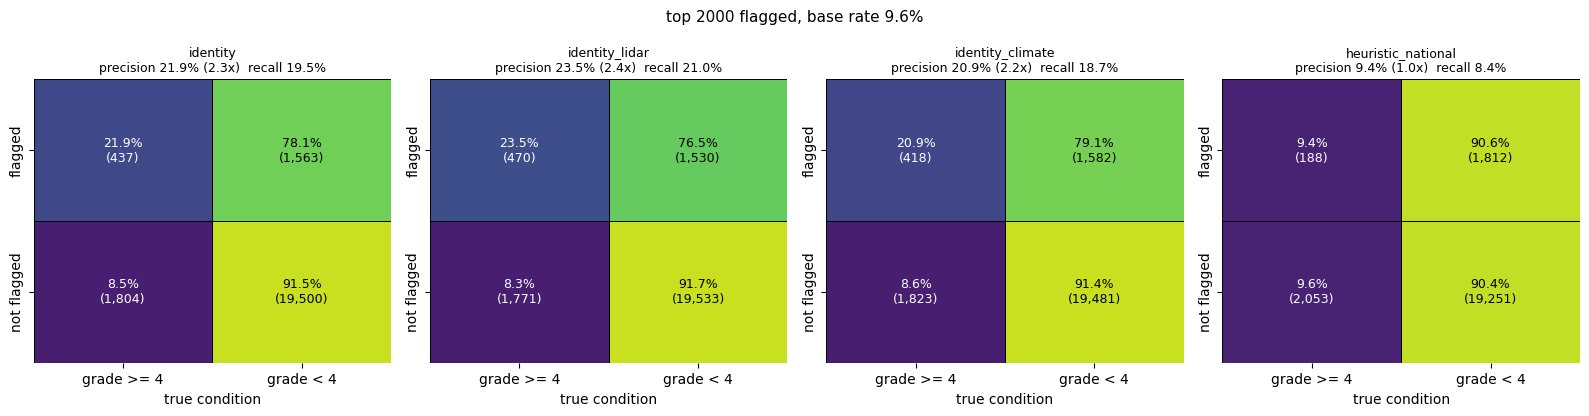

In [55]:

budget = 2000
base_rate = 0.096164

fig, axes = plt.subplots(1, len(matrix_labels), figsize=(4 * len(matrix_labels), 4.2))

for ax, label in zip(axes, matrix_labels):
    ranked = sweep_oof.filter(pl.col("label") == label).sort("score", descending=True)
    positives = ranked.get_column("is_positive").to_numpy()

    true_positive = int(positives[:budget].sum())
    false_positive = budget - true_positive
    false_negative = int(positives[budget:].sum())
    true_negative = len(positives) - budget - false_negative

    counts = np.array([[true_positive, false_positive], [false_negative, true_negative]])
    shares = counts / counts.sum(axis=1, keepdims=True)

    sns.heatmap(
        shares,
        cmap="viridis",
        vmin=0,
        vmax=1,
        cbar=False,
        xticklabels=["grade >= 4", "grade < 4"],
        yticklabels=["flagged", "not flagged"],
        ax=ax,
        linewidths=0.5,
        linecolor="black",
    )

    for i in range(2):
        for j in range(2):
            ax.text(
                j + 0.5,
                i + 0.5,
                f"{shares[i, j]:.1%}\n({counts[i, j]:,})",
                ha="center",
                va="center",
                fontsize=9,
                color="white" if shares[i, j] < 0.6 else "black",
            )

    precision = true_positive / budget
    recall = true_positive / (true_positive + false_negative)
    ax.set_title(
        f"{label}\nprecision {precision:.1%} ({precision / base_rate:.1f}x)  recall {recall:.1%}",
        fontsize=9,
    )
    ax.set_xlabel("true condition")
    ax.set_ylabel("")

fig.suptitle(f"top {budget} flagged, base rate {base_rate:.1%}", fontsize=11)
fig.tight_layout()
plt.show()

i think these matrices (esp the 200 asset one) are good visualisations to show how the models start to outperform the heuristics in the part of the flood defense asset population that matters. 

obviously needs caveating that the heuristics don't actually have a "top 200 most confident" equivilent, so its just an arbritary slice of the assets in that case, perhaps not directly comparible but is kind of the  point 

In [57]:
output_dir = paths.report_data

sweep_curve.write_parquet(output_dir / "nb_19_sweep_curve_by_family.parquet")

In [58]:
config_delta.write_parquet(output_dir / "nb_19_config_delta.parquet")